Wernike's data tested with Broca's LV-MAE models (trained on "yes" vs "no" on 9 health participants)

# Clone code

In [1]:
# Visuals
!rm -rf SpeckleAI_Visuals/
!git clone https://github.com/danielrubinsteinishere/SpeckleAI_Visuals.git
import sys
sys.path.append('/content/SpeckleAI_Visuals')

from plots.bar_plots import plot_subject_metrics
from stats.eval import summarize
from cm.binary_cms import plot_binary_confusion_matrix_from_cm, create_image_with_multiple_binary_confusion_matrices, create_image_with_mean_binary_confusion_matrix
from cm.multiclass_cms import display_multiclass_cm_with_percents
from metrics.metrics import macro_F1_from_cm, macro_F1_accuracy_from_cm, calc_mean_acc_and_F1, create_mean_cm

# Models:
!rm -rf SpecklesAI/

#if you are clonning a public version, use:
!git clone https://github.com/natalyasegal/SpecklesAI.git

!cp SpecklesAI/config/config_compehension_E_S.py SpecklesAI/config/config.py #pay attention to this

import sys
sys.path.append('/content/SpecklesAI')   # add package root to Python path

#from utils.swap import swap_categories
from config.config import binarize_lables, load_yaml, Configuration, Configuration_Minimal
from utils.norm import normalize_per_fixedclip
from utils.swap import *
from utils.stats import print_stats, print_test_stats
from utils.formatstranslator import make_x_per_category, test2trainformat, limit_rearrange_and_flatten_s
from utils.data import split_by_chunks, split_from_start, load_dataset_x, concatenate_train_or_val
from utils.utils import save_dataset_x, save_dataset
from utils.embeddings_utils import concat_temporal_embeddings # sliding window -> target size: N-k+1
from utils.utils_seed import set_seed_all
from preprocessing.preprocessing import unison_shuffled_copies
from pca.pca import visualize_embeddings_pca_3d
from models.LvMAE_pt import VideoMAE
from models.LvMAE_pt import *
from models.binary_XGBoost import train_eval_xgboost_classifier
from models.multiclass_XGBoost import train_eval_xgboost_classifier_multiclass, train_eval_xgb_train_api_multiclass, get_multiclass_cm_with_percents
from models.XGBoost_on_LV_MAE_embeddings import train_and_eval_classifier_on_embeddings, train_and_eval_multiclass_classifier_on_embeddings
from evaluation.eval import calc_accumulated_predictions, generate_confusion_matrix_image, plot_nice_roc_curve, find_optimal_threshold, evaluate_model, evaluate_per_chunk, flatten_accumulated
from evaluation.eval_utils import eval_aggregated_test_set_th_on_val, eval_aggregated_th_on_target_subj_firstK_chunks
from pca.pca_on_embeddings import create_and_visualize_embeddings_3d, create_and_visualize_embeddings_multiclass_3d

set_seed_all(seed_for_init=1, random_seed=9, use_tf = False)

# imports:
from sklearn.metrics import confusion_matrix

Cloning into 'SpeckleAI_Visuals'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 79 (delta 28), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 350.00 KiB | 2.71 MiB/s, done.
Resolving deltas: 100% (28/28), done.
Cloning into 'SpecklesAI'...
remote: Enumerating objects: 1332, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 1332 (delta 20), reused 0 (delta 0), pack-reused 1284 (from 2)
Receiving objects: 100% (1332/1332), 35.75 MiB | 18.19 MiB/s, done.
Resolving deltas: 100% (742/742), done.
[set_seed] All seeds set (seed_for_init=1, random_seed=9).


### old

In [ ]:
# Visuals
!rm -rf SpeckleAI_Visuals/
!git clone https://github.com/danielrubinsteinishere/SpeckleAI_Visuals.git
import sys
sys.path.append('/content/SpeckleAI_Visuals')

from plots.bar_plots import plot_subject_metrics
from stats.eval import summarize
from cm.binary_cms import create_image_with_multiple_binary_confusion_matrices, create_image_with_mean_binary_confusion_matrix

# Models:
!rm -rf SpecklesAI/

#if you are clonning a public version, use:
!git clone https://github.com/natalyasegal/SpecklesAI.git

!cp SpecklesAI/config/config_compehension_E_S.py SpecklesAI/config/config.py #pay attention to this

import sys
sys.path.append('/content/SpecklesAI')   # add package root to Python path

#from utils.swap import swap_categories
from config.config import binarize_lables, load_yaml, Configuration, Configuration_Minimal
from utils.norm import normalize_per_fixedclip
from utils.swap import *
from utils.stats import print_stats, print_test_stats
from utils.formatstranslator import make_x_per_category, test2trainformat, limit_rearrange_and_flatten_s
from utils.data import split_by_chunks, split_from_start, load_dataset_x, concatenate_train_or_val
from utils.utils import save_dataset_x, save_dataset
from utils.embeddings_utils import concat_temporal_embeddings # sliding window -> target size: N-k+1
from utils.utils_seed import set_seed_all
from preprocessing.preprocessing import unison_shuffled_copies
from models.LvMAE_pt import VideoMAE
from models.LvMAE_pt import *
from models.binary_XGBoost import train_eval_xgboost_classifier
from models.multiclass_XGBoost import train_eval_xgboost_classifier_multiclass
from models.XGBoost_on_LV_MAE_embeddings import train_and_eval_classifier_on_embeddings, train_and_eval_multiclass_classifier_on_embeddings
from evaluation.eval import calc_accumulated_predictions, generate_confusion_matrix_image, plot_nice_roc_curve, find_optimal_threshold, evaluate_model, evaluate_per_chunk, flatten_accumulated
from evaluation.eval_utils import eval_aggregated_test_set_th_on_val, eval_aggregated_th_on_target_subj_firstK_chunks

set_seed_all(seed_for_init=1, random_seed=9, use_tf = False)

# imports:
from sklearn.metrics import confusion_matrix

Cloning into 'SpeckleAI_Visuals'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 39 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (39/39), 338.55 KiB | 11.28 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Cloning into 'SpecklesAI'...
remote: Enumerating objects: 1252, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 1252 (delta 100), reused 0 (delta 0), pack-reused 1088 (from 1)
Receiving objects: 100% (1252/1252), 35.72 MiB | 13.60 MiB/s, done.
Resolving deltas: 100% (699/699), done.
[set_seed] All seeds set (seed_for_init=1, random_seed=9).


# Print versions

In [ ]:
import sys, platform, torch, torchvision

print("Python version:", sys.version.split()[0])
print("Platform:", platform.platform())

# Core scientific stack
import numpy as np, pandas as pd, matplotlib, sklearn
print("Numpy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

# PyTorch and related
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

# Video / data utilities (if applicable)
try:
    import decord
    print("Decord:", decord.__version__)
except:
    pass

try:
    import av
    print("PyAV:", av.__version__)
except:
    pass

# XGBoost or LightGBM (if used)
try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except:
    pass

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except:
    pass

# Transformers / MAE-related models (if using HuggingFace)
try:
    import transformers
    print("Transformers:", transformers.__version__)
except:
    pass


# PyTorch and related
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

# Video / data utilities (if applicable)
try:
    import decord
    print("Decord:", decord.__version__)
except:
    pass

try:
    import av
    print("PyAV:", av.__version__)
except:
    pass

# XGBoost or LightGBM (if used)
try:
    import xgboost
    print("XGBoost:", xgboost.__version__)
except:
    pass

try:
    import lightgbm
    print("LightGBM:", lightgbm.__version__)
except:
    pass

# Transformers / MAE-related models (if using HuggingFace)
try:
    import transformers
    print("Transformers:", transformers.__version__)
except:
    pass


Python version: 3.12.12
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Numpy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91002
XGBoost: 3.2.0
LightGBM: 4.6.0
Transformers: 5.0.0
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91002
XGBoost: 3.2.0
LightGBM: 4.6.0
Transformers: 5.0.0


# Mount

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Create npy
- run once, copy to drive
- copy from drive for the next session

### list

In [ ]:
!ls gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/second_batch

exp3_1_Eitan_19Nov24_F_midday.zip  exp3_1_Ofir_19Nov24.zip
exp3_1_Eitan_19Nov24_midday.zip    exp3_1_Yehor_19Nov24_F_midday.zip
exp3_1_Eitan_19Nov24.zip	   exp3_1_Yehor_19Nov24_F.zip
exp3_1_Ofir_19Nov24_F_midday.zip   exp3_1_Yehor_19Nov24_midday.zip
exp3_1_Ofir_19Nov24_F.zip	   exp3_1_Yehor_19Nov24.zip
exp3_1_Ofir_19Nov24_midday.zip


In [ ]:
!ls -l gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data//*.zip| grep Sergey

-rw------- 1 root root  5342790698 Aug  1  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_1Aug_Sergey_1.zip
-rw------- 1 root root  1105754335 Aug  1  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_1Aug_Sergey_2.zip
-rw------- 1 root root  1175432343 Aug  1  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_1Aug_Sergey_3.zip
-rw------- 1 root root   737808011 Dec 25  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_1_Sergey_25Dec23.zip
-rw------- 1 root root  3547869945 Dec 26  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_1_Sergey_26Dec23.zip
-rw------- 1 root root  9548234918 Jan 12  2024 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_1_Sergey_8Jan24.zip
-rw------- 1 root root  2906118896 Jun 20  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_4_Sergey_take2_Wernicke.zip
-rw------- 1 root root   760503592 Jul  6  2023 gdrive/My D

In [ ]:
!ls -l gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data//*.zip| grep Yafim

-rw------- 1 root root  5159099982 Nov 26  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//2_exp3_Yafim_26Nov2023.zip
-rw------- 1 root root  3212150018 Jan 13  2024 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//3_exp3_1_Yafim_8Jan24.zip
-rw------- 1 root root 11089571022 Jun 17  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_1_take5_Yafim_Wernicke.zip
-rw------- 1 root root   612836424 Jun 18  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_1_take6_Yafim_Wernicke.zip
-rw------- 1 root root   925718327 Jul 11  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_1_take7_Yafim_test_native_music.zip
-rw------- 1 root root  3875723955 Dec 28  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_1_Yafim_28Dec23.zip
-rw------- 1 root root  3388609076 Nov 26  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_Yafim_26Nov2023.zip
-rw------- 1 root root    14885617

In [ ]:
!ls -l gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data//*.zip| grep Natalya

-rw------- 1 root root  4806458339 Nov 26  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//2_exp3_Natalya_26Nov2023.zip
-rw------- 1 root root  1736873684 Jun 18  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_3_take4_Natalya_Wernicke.zip
-rw------- 1 root root  1291294247 Jun 18  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_3_take5_Natalya_Wernicke.zip
-rw------- 1 root root   231992828 Jun 19  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_3_take6_Natalya_Wernicke.zip
-rw------- 1 root root   366753498 Jul  6  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//___exp3_3_take7_Natalya_test.zip
-rw------- 1 root root   366754560 Jul  6  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//exp3_3_take7_Wernicke_Natalya_test.zip
-rw------- 1 root root  3252920797 Nov 26  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_Natalya_26Nov2023.zip


In [ ]:
!ls -l gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data//*.zip| grep ZEEV

-rw------- 1 root root  4926690762 Nov 26  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//2_exp3_ZEEV.zip
-rw------- 1 root root  3310275232 Nov 26  2023 gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data//_exp3_ZEEV.zip


### Morning

####1
- Alon

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_1_Alon_26Dec23.zip
!ls exp3_1_Alon_26Dec23/261223_day1_1/Alon/Wernike/english
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_1_Alon_26Dec23/261223_day1_1/Alon/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__1.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__1.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_1_Alon_26Dec23.zip
replace exp3_1_Alon_26Dec23/261223_day1/Alon/Wernike/english/acA1440-220um__40034984__20231226_112322190.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: exp3_1_Alon_26Dec23/261223_day1/Alon/Wernike/english/acA1440-220um__40034984__20231226_112322190.avi  
  inflating: exp3_1_Alon_26Dec23/261223_day1/Alon/Wernike/english/acA1440-220um__40034984__20231226_112335112.avi  
  inflating: exp3_1_Alon_26Dec23/261223_day1/Alon/Wernike/english/acA1440-220um__40034984__20231226_112346282.avi  
  inflating: exp3_1_Alon_26Dec23/261223_day1/Alon/Wernike/english/acA1440-220um__40034984__20231226_112424306.avi  
  inflating: exp3_1_Alon_26Dec23/261223_day1/Alon/Wernike/english/acA1440-220um__40034984__20231226_112435105.avi  
  inflating: exp3_1_Alon_26Dec23/261223_day1/Alon/Wernike/english/acA1440-220um__40034984__20231226_112445760.avi  
  inflat

####2
- Zeev

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_ZEEV.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/2_exp3_ZEEV.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_ZEEV/26112023_day1/Zeev/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__2.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__2.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_ZEEV.zip
replace exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093345191.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093345191.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093357681.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093409504.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093421143.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093436761.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__40034984__20231126_093448708.avi  
  inflating: exp3_ZEEV/26112023_day1/Zeev/Wernike/english/acA1440-220um__4

####3
- Dima

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_1_Dima_28Dec23.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_6_Dimka_take2_Wernicke.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__3.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__3.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_1_Dima_28Dec23.zip
replace exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike/english/acA1440-220um__40034984__20231228_121114351.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike/english/acA1440-220um__40034984__20231228_121114351.avi  
  inflating: exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike/english/acA1440-220um__40034984__20231228_121125146.avi  
  inflating: exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike/english/acA1440-220um__40034984__20231228_121135744.avi  
  inflating: exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike/english/acA1440-220um__40034984__20231228_121149234.avi  
  inflating: exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike/english/acA1440-220um__40034984__20231228_121302880.avi  
  inflating: exp3_1_Dima_28Dec23/281223_day1/Dima/Wernike/english/acA1440-220um__40034984__20231228_121314833.avi  
  inflat

####4
- Jenya

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/2_exp3_Yevgeni_26Nov2023.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_Yevgeni_26Nov2023.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_d6ay1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__4.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__4.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/2_exp3_Yevgeni_26Nov2023.zip
replace exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike/english/acA1440-220um__40034984__20231126_102842877.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike/english/acA1440-220um__40034984__20231126_102842877.avi  
  inflating: exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike/english/acA1440-220um__40034984__20231126_102854586.avi  
  inflating: exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike/english/acA1440-220um__40034984__20231126_102910148.avi  
  inflating: exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike/english/acA1440-220um__40034984__20231126_102922563.avi  
  inflating: exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike/english/acA1440-220um__40034984__20231126_102935313.avi  
  inflating: exp3_Yevgeni_26Nov2023/2611023_day1/Yevgeni/Wernike/english/acA14

####5
- Yafim

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_1_take5_Yafim_Wernicke.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/2_exp3_Yafim_26Nov2023.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/3_exp3_1_Yafim_8Jan24.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_1_take5_Yafim_Wernicke.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_1_take6_Yafim_Wernicke.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_1_take5_Yafim_Wernicke/12062023_day1/Yafim/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__5.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__5.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_1_take5_Yafim_Wernicke.zip
replace exp3_1_take5_Yafim_Wernicke/12062023_day1/Yafim/Wernike/english/acA1440-220um__40034984__20230612_135657085.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: exp3_1_take5_Yafim_Wernicke/12062023_day1/Yafim/Wernike/english/acA1440-220um__40034984__20230612_135657085.avi  
  inflating: exp3_1_take5_Yafim_Wernicke/12062023_day1/Yafim/Wernike/english/acA1440-220um__40034984__20230612_135711899.avi  
  inflating: exp3_1_take5_Yafim_Wernicke/12062023_day1/Yafim/Wernike/english/acA1440-220um__40034984__20230612_135723697.avi  
  inflating: exp3_1_take5_Yafim_Wernicke/12062023_day1/Yafim/Wernike/english/acA1440-220um__40034984__20230612_135735650.avi  
  inflating: exp3_1_take5_Yafim_Wernicke/12062023_day1/Yafim/Wernike/english/acA1440-220um__40034984__20230612_135748054.avi  
  inflating: exp3_1_take5_Yafim_Wernicke/12062023_d

####6
- Sergey

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_1Aug_Sergey_1.zip
#exp3_4_Sergey_take4_Wernicke.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_1Aug_Sergey_1/1082023_day1/Sergey/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__6.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__6.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/_exp3_1Aug_Sergey_1.zip
replace exp3_1Aug_Sergey_1/1082023_day1/Sergey/Wernike/english/acA1440-220um__40034984__20230801_111654643.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace exp3_1Aug_Sergey_1/1082023_day1/Sergey/Wernike/english/acA1440-220um__40034984__20230801_111654643.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: 
error:  invalid response [{ENTER}]
replace exp3_1Aug_Sergey_1/1082023_day1/Sergey/Wernike/english/acA1440-220um__40034984__20230801_111654643.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace exp3_1Aug_Sergey_1/1082023_day1/Sergey/Wernike/english/acA1440-220um__40034984__20230801_111654643.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace exp3_1Aug_Sergey_1/1082023_day1/Sergey/Wernike/english/acA1440-220um__40034984__20230801_111654643.avi? [y]es, [n

####7
- Eithan (Bar Ilan)

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/second_batch/exp3_1_Eitan_19Nov24.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_1_Eitan_19Nov24_midday.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__7.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__7.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/second_batch/exp3_1_Eitan_19Nov24.zip
replace exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike/english/acA1440-220um__40034984__20241119_112231378.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike/english/acA1440-220um__40034984__20241119_112231378.avi  
  inflating: exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike/english/acA1440-220um__40034984__20241119_112253516.avi  
  inflating: exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike/english/acA1440-220um__40034984__20241119_112306398.avi  
  inflating: exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike/english/acA1440-220um__40034984__20241119_112318310.avi  
  inflating: exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike/english/acA1440-220um__40034984__20241119_112330238.avi  
  inflating: exp3_1_Eitan_19Nov24/19112024-day1/Eitan/Wernike/english/acA1440-220um__40

####8
- Yehor

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/second_batch/exp3_1_Yehor_19Nov24.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning___8.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__8.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/second_batch/exp3_1_Yehor_19Nov24.zip
replace exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike/english/acA1440-220um__40034984__20241119_115716621.avi? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike/english/acA1440-220um__40034984__20241119_115716621.avi  
  inflating: exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike/english/acA1440-220um__40034984__20241119_115729421.avi  
  inflating: exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike/english/acA1440-220um__40034984__20241119_115741471.avi  
  inflating: exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike/english/acA1440-220um__40034984__20241119_115753543.avi  
  inflating: exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike/english/acA1440-220um__40034984__20241119_115805833.avi  
  inflating: exp3_1_Yehor_19Nov24/19112024-day1/Yehor/Wernike/english/acA1440-220um__40

####9
- Ofir

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/second_batch/exp3_1_Ofir_19Nov24.zip
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__9.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__9.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/second_batch/exp3_1_Ofir_19Nov24.zip
   creating: exp3_1_Ofir_19Nov24/
   creating: exp3_1_Ofir_19Nov24/19112024-day1/
   creating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/
   creating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike/
   creating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike/english/
  inflating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike/english/acA1440-220um__40034984__20241119_103105656.avi  
  inflating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike/english/acA1440-220um__40034984__20241119_103118174.avi  
  inflating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike/english/acA1440-220um__40034984__20241119_103145680.avi  
  inflating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike/english/acA1440-220um__40034984__20241119_103200130.avi  
  inflating: exp3_1_Ofir_19Nov24/19112024-day1/Ofir/Wernike/english/acA1440-220um__40034984__20241119_103228906.avi  
  inflating: exp3_1_Ofir_19Nov24/191120

####10
- Eithan L.

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_2_partial.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_9_Daniel_take2_Wernicke.zip
!ls exp3_2_partial/02042023_day1/Ethan/Wernike/english
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_2_partial/02042023_day1/Ethan/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__10.npy

!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__10.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

rm: cannot remove 'data': No such file or directory
rm: cannot remove 'exp3': No such file or directory
Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_2_partial.zip
   creating: exp3_2_partial/
   creating: exp3_2_partial/02042023_day1/
   creating: exp3_2_partial/02042023_day1/Ethan/
   creating: exp3_2_partial/02042023_day1/Ethan/aSTG/
   creating: exp3_2_partial/02042023_day1/Ethan/aSTG/english/
  inflating: exp3_2_partial/02042023_day1/Ethan/aSTG/english/0001.avi  
  inflating: exp3_2_partial/02042023_day1/Ethan/aSTG/english/0002.avi  
  inflating: exp3_2_partial/02042023_day1/Ethan/aSTG/english/0003.avi  
  inflating: exp3_2_partial/02042023_day1/Ethan/aSTG/english/0004.avi  
  inflating: exp3_2_partial/02042023_day1/Ethan/aSTG/english/0005.avi  
   creating: exp3_2_partial/02042023_day1/Ethan/aSTG/mother_tonque/
  inflating: exp3_2_partial/02042023_day1/Ethan/aSTG/mother_tonque/0001.avi  
  inflating: exp3_2_partial/02042023_day1/Ethan/aSTG/mother_tonqu

####11
- Natalya


In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_3_take5_Natalya_Wernicke.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_3_take6_Natalya_Wernicke.zip
!ls exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike/english
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__11.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__11.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_3_take5_Natalya_Wernicke.zip
   creating: exp3_3_take5_Natalya_Wernicke/
   creating: exp3_3_take5_Natalya_Wernicke/18062023_day1/
   creating: exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/
   creating: exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike/
   creating: exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike/english/
  inflating: exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike/english/acA1440-220um__40034984__20230618_142935555.avi  
  inflating: exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike/english/acA1440-220um__40034984__20230618_142946551.avi  
  inflating: exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike/english/acA1440-220um__40034984__20230618_142957481.avi  
  inflating: exp3_3_take5_Natalya_Wernicke/18062023_day1/Natalya/Wernike/english/acA1440-220um__40034984__20230618_143008431.avi  
  inflating: exp3_3_take5_Natalya_Wernicke/180620

####12
- Daniel

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_9_Daniel_Wernicke.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_9_Daniel_take2_Wernicke.zip
!ls exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__12.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__12.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_9_Daniel_Wernicke.zip
   creating: exp3_9_Daniel_Wernicke/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/
   creating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124115962.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124128724.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124141642.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124154145.avi  
  inflating: exp3_9_Daniel_Wernicke/5062023_day1/Daniel/Wernike/english/acA1440-220um__40034984__20230605_124206882.avi  
  inflating:

####13
- Yoni

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_8_Wernicke.zip
#!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_8_take2_Wernicke.zip
!ls exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_8_Wernicke/15052023_day1/Yoni/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__13.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__13.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_8_Wernicke.zip
   creating: exp3_8_Wernicke/
   creating: exp3_8_Wernicke/15052023_day1/
   creating: exp3_8_Wernicke/15052023_day1/Yoni/
   creating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/
   creating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english/
  inflating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english/acA1440-220um__40034984__20230515_113824522.avi  
  inflating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english/acA1440-220um__40034984__20230515_113848895.avi  
  inflating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english/acA1440-220um__40034984__20230515_113904261.avi  
  inflating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english/acA1440-220um__40034984__20230515_113918368.avi  
  inflating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english/acA1440-220um__40034984__20230515_113930769.avi  
  inflating: exp3_8_Wernicke/15052023_day1/Yoni/Wernike/english/acA1440-220um__40034984__2023051

####14 - missing  English
- Kira, missing English

In [ ]:
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_7_Wernicke.zip

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_7_Wernicke.zip
   creating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/
   creating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_113815113.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_113936892.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_114011931.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_114102671.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_114201616.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_115034938.avi  
   creating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_

In [ ]:
!rm -r data
!rm -r exp3
!unzip gdrive/My\ Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_7_Wernicke.zip
!ls exp3_7_Wernicke/30042023_day1/Kira/Wernike/english
!mkdir exp3
!mkdir exp3/somedate_day1_1
!mkdir exp3/somedate_day1_1/SubjectOneName
!mv exp3_7_Wernicke/30042023_day1/Kira/Wernike exp3/somedate_day1_1/SubjectOneName/.
!ls exp3/somedate_day1_1/SubjectOneName/Wernike
!python -u SpecklesAI/prepare_test_sets.py --split_num 1 --random_seed 9  --test_set_per_category_file test_per_category_split_morning_
!mv test_per_category_split_morning__1.npy test_compr2_per_category_split_morning__14.npy
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/
!cp test_compr2_per_category_split_morning__14.npy gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/

Archive:  gdrive/My Drive/__MSc_2023/code_and_data/experiment_3/data/exp3_7_Wernicke.zip
   creating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/
   creating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_113815113.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_113936892.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_114011931.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_114102671.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_114201616.avi  
  inflating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_tonque/acA1440-220um__40034984__20230430_115034938.avi  
   creating: exp3_7_Wernicke/30042023_day1/Kira/Wernike/mother_

# Create datasets

## copy npys from drive

In [3]:
!cp gdrive/MyDrive/__PHd_2025/code_and_data/npys_comprehension_add_E_S/morning/*.npy .
!ls -l

total 2700092
drwx------  5 root root      4096 Apr  9 13:23 gdrive
drwxr-xr-x  1 root root      4096 Mar 30 13:34 sample_data
drwxr-xr-x  8 root root      4096 Apr  9 13:22 SpeckleAI_Visuals
drwxr-xr-x 12 root root      4096 Apr  9 13:22 SpecklesAI
-rw-------  1 root root 204800128 Apr  9 13:23 test_compr2_per_category_split_morning__10.npy
-rw-------  1 root root 204800128 Apr  9 13:23 test_compr2_per_category_split_morning__11.npy
-rw-------  1 root root 204800128 Apr  9 13:23 test_compr2_per_category_split_morning__12.npy
-rw-------  1 root root 204800128 Apr  9 13:23 test_compr2_per_category_split_morning__13.npy
-rw-------  1 root root 102400128 Apr  9 13:23 test_compr2_per_category_split_morning__1.npy
-rw-------  1 root root 204800128 Apr  9 13:24 test_compr2_per_category_split_morning__2.npy
-rw-------  1 root root 204800128 Apr  9 13:24 test_compr2_per_category_split_morning__3.npy
-rw-------  1 root root 204800128 Apr  9 13:24 test_compr2_per_category_split_morning__4.npy
-r

## test format

### morning

In [4]:
#morning
test_norm_on = False # change if needed
test_1_m = load_dataset_x("test_compr2_per_category_split_morning__1.npy", with_normalization = test_norm_on)
test_2_m = load_dataset_x("test_compr2_per_category_split_morning__2.npy", with_normalization = test_norm_on)
test_3_m = load_dataset_x("test_compr2_per_category_split_morning__3.npy", with_normalization = test_norm_on)
test_4_m = load_dataset_x("test_compr2_per_category_split_morning__4.npy", with_normalization = test_norm_on)
test_5_m = load_dataset_x("test_compr2_per_category_split_morning__5.npy", with_normalization = test_norm_on)
test_6_m = load_dataset_x("test_compr2_per_category_split_morning__6.npy", with_normalization = test_norm_on)
test_7_m = load_dataset_x("test_compr2_per_category_split_morning__7.npy", with_normalization = test_norm_on)
test_8_m = load_dataset_x("test_compr2_per_category_split_morning__8.npy", with_normalization = test_norm_on)
test_9_m = load_dataset_x("test_compr2_per_category_split_morning__9.npy", with_normalization = test_norm_on)
test_10_m = load_dataset_x("test_compr2_per_category_split_morning__10.npy", with_normalization = test_norm_on)
test_11_m = load_dataset_x("test_compr2_per_category_split_morning__11.npy", with_normalization = test_norm_on)
test_12_m = load_dataset_x("test_compr2_per_category_split_morning__12.npy", with_normalization = test_norm_on)
test_13_m = load_dataset_x("test_compr2_per_category_split_morning__13.npy", with_normalization = test_norm_on)

Loading test_compr2_per_category_split_morning__1.npy
Loading test_compr2_per_category_split_morning__2.npy
Loading test_compr2_per_category_split_morning__3.npy
Loading test_compr2_per_category_split_morning__4.npy
Loading test_compr2_per_category_split_morning__5.npy
Loading test_compr2_per_category_split_morning__6.npy
Loading test_compr2_per_category_split_morning__7.npy
Loading test_compr2_per_category_split_morning__8.npy
Loading test_compr2_per_category_split_morning__9.npy
Loading test_compr2_per_category_split_morning__10.npy
Loading test_compr2_per_category_split_morning__11.npy
Loading test_compr2_per_category_split_morning__12.npy
Loading test_compr2_per_category_split_morning__13.npy


#### norm + gain and train / val format
- just formats, not dividing into sets yet

##### n_chunks_per_clip = 1

In [5]:
norm_mode = "minmax" #"standard"
gain = 10.0
n_chunks_per_clip = 1 # consider 5000 for norm per clip
test_1_m_n_40ms = normalize_per_fixedclip(test_1_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_2_m_n_40ms = normalize_per_fixedclip(test_2_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_3_m_n_40ms = normalize_per_fixedclip(test_3_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_4_m_n_40ms = normalize_per_fixedclip(test_4_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_5_m_n_40ms = normalize_per_fixedclip(test_5_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_6_m_n_40ms = normalize_per_fixedclip(test_6_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_7_m_n_40ms = normalize_per_fixedclip(test_7_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_8_m_n_40ms = normalize_per_fixedclip(test_8_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_9_m_n_40ms = normalize_per_fixedclip(test_9_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_10_m_n_40ms = normalize_per_fixedclip(test_10_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_11_m_n_40ms = normalize_per_fixedclip(test_11_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_12_m_n_40ms = normalize_per_fixedclip(test_12_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
test_13_m_n_40ms = normalize_per_fixedclip(test_13_m, n_chunks_per_clip=n_chunks_per_clip, mode=norm_mode, gain=gain)
print(f"test_1_m_n.shape = {test_1_m_n_40ms.shape}")
print(f"test_2_m_n.shape = {test_2_m_n_40ms.shape}")
print(f"test_3_m_n.shape = {test_3_m_n_40ms.shape}")
print(f"test_5_m_n.shape = {test_5_m_n_40ms.shape}")
print(f"test_6_m_n.shape = {test_6_m_n_40ms.shape}")
print(f"test_4_m_n.shape = {test_4_m_n_40ms.shape}")
print(f"test_7_m_n.shape = {test_7_m_n_40ms.shape}")
print(f"test_8_m_n.shape = {test_8_m_n_40ms.shape}")
print(f"test_9_m_n.shape = {test_9_m_n_40ms.shape}")
print(f"test_10_m_n.shape = {test_10_m_n_40ms.shape}")
print(f"test_11_m_n.shape = {test_11_m_n_40ms.shape}")
print(f"test_12_m_n.shape = {test_12_m_n_40ms.shape}")
print(f"test_13_m_n.shape = {test_13_m_n_40ms.shape}")
x1_n_40ms, y1_n_40ms = test2trainformat(test_1_m_n_40ms, need_to_shuffle_within_category = False)
x2_n_40ms, y2_n_40ms = test2trainformat(test_2_m_n_40ms, need_to_shuffle_within_category = False)
x3_n_40ms, y3_n_40ms = test2trainformat(test_3_m_n_40ms, need_to_shuffle_within_category = False)
x4_n_40ms, y4_n_40ms = test2trainformat(test_4_m_n_40ms, need_to_shuffle_within_category = False)
x5_n_40ms, y5_n_40ms = test2trainformat(test_5_m_n_40ms, need_to_shuffle_within_category = False)
x6_n_40ms, y6_n_40ms = test2trainformat(test_6_m_n_40ms, need_to_shuffle_within_category = False)
x7_n_40ms, y7_n_40ms = test2trainformat(test_7_m_n_40ms, need_to_shuffle_within_category = False)
x8_n_40ms, y8_n_40ms = test2trainformat(test_8_m_n_40ms, need_to_shuffle_within_category = False)
x9_n_40ms, y9_n_40ms = test2trainformat(test_9_m_n_40ms, need_to_shuffle_within_category = False)
x10_n_40ms, y10_n_40ms = test2trainformat(test_10_m_n_40ms, need_to_shuffle_within_category = False)
x11_n_40ms, y11_n_40ms = test2trainformat(test_11_m_n_40ms, need_to_shuffle_within_category = False)
x12_n_40ms, y12_n_40ms = test2trainformat(test_12_m_n_40ms, need_to_shuffle_within_category = False)
x13_n_40ms, y13_n_40ms = test2trainformat(test_13_m_n_40ms, need_to_shuffle_within_category = False)

test_1_m_n.shape = (2, 1250, 40, 32, 32, 1)
test_2_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_3_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_5_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_6_m_n.shape = (2, 5000, 40, 32, 32, 1)
test_4_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_7_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_8_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_9_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_10_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_11_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_12_m_n.shape = (2, 2500, 40, 32, 32, 1)
test_13_m_n.shape = (2, 2500, 40, 32, 32, 1)
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000
max_chanks per category=500000


# Print stats

#### test format with norm 40 ms

In [ ]:
print_test_stats(test_1_m_n_40ms)
print_test_stats(test_3_m_n_40ms)
print_test_stats(test_3_m_n_40ms)
print_test_stats(test_4_m_n_40ms)
print_test_stats(test_5_m_n_40ms)
print_test_stats(test_6_m_n_40ms)
print_test_stats(test_7_m_n_40ms)
print_test_stats(test_8_m_n_40ms)
print_test_stats(test_9_m_n_40ms)
print_test_stats(test_10_m_n_40ms)
print_test_stats(test_11_m_n_40ms)
print_test_stats(test_12_m_n_40ms)
print_test_stats(test_13_m_n_40ms)

 | full shape = (2, 1250, 40, 32, 32, 1)
  class 0: mean=1.629, SD=0.261, min=0.701, max=2.564, n_chunks=1250
  class 1: mean=0.975, SD=0.105, min=0.678, max=1.453, n_chunks=1250
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=2.736, SD=0.322, min=1.543, max=3.793, n_chunks=2500
  class 1: mean=1.713, SD=0.240, min=0.958, max=2.857, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=2.736, SD=0.322, min=1.543, max=3.793, n_chunks=2500
  class 1: mean=1.713, SD=0.240, min=0.958, max=2.857, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=2.909, SD=0.066, min=2.715, max=3.216, n_chunks=2500
  class 1: mean=2.951, SD=0.071, min=2.731, max=3.244, n_chunks=2500
 | full shape = (2, 2500, 40, 32, 32, 1)
  class 0: mean=2.685, SD=0.150, min=2.205, max=3.193, n_chunks=2500
  class 1: mean=2.824, SD=0.101, min=2.518, max=3.185, n_chunks=2500
 | full shape = (2, 5000, 40, 32, 32, 1)
  class 0: mean=2.773, SD=0.152, min=2.280, max=3.324, n_chunks=

# LV-MAE training - not used, here for referene
- for reference here

#### Train


In [ ]:
train_x_e, train_y_e=concatenate_train_or_val([x1_n,x2_n,x4_n,x5_n,x6_n,x7_n,x8_n,x9_n,x10_n], [y1_n,y2_n,y4_n,y5_n,y6_n,y7_n,y8_n,y9_n,y10_n])
results = run_end_to_end(
         X=train_x_e, y=train_y_e,
         normalize=False,
         mae_embed_dim=128,   # encoder width
         proj_dim=128,        # final embedding size
         mae_epochs=20,
         mae_batch=64,
         mask_ratio=0.9,
         pool="cls",
         seed=9)

==> Training LVMAE (self-supervised) on TRAIN split ...
[MAE] Epoch 1/20 | loss=3.8254
[MAE] Epoch 2/20 | loss=3.7631
[MAE] Epoch 3/20 | loss=3.7622
[MAE] Epoch 4/20 | loss=3.7616
[MAE] Epoch 5/20 | loss=3.7617
[MAE] Epoch 6/20 | loss=3.6657
[MAE] Epoch 7/20 | loss=3.3984
[MAE] Epoch 8/20 | loss=3.3968
[MAE] Epoch 9/20 | loss=3.3958
[MAE] Epoch 10/20 | loss=3.3956
[MAE] Epoch 11/20 | loss=3.3949
[MAE] Epoch 12/20 | loss=3.3117
[MAE] Epoch 13/20 | loss=3.1939
[MAE] Epoch 14/20 | loss=2.8164
[MAE] Epoch 15/20 | loss=2.6749
[MAE] Epoch 16/20 | loss=2.6715
[MAE] Epoch 17/20 | loss=2.6689
[MAE] Epoch 18/20 | loss=2.6670
[MAE] Epoch 19/20 | loss=2.6656
[MAE] Epoch 20/20 | loss=2.6640
[save_lvmae_checkpoint] Saved to /content/artifacts_lvmae_1/checkpoint.pt


#### Save in drive

In [ ]:
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1
!mkdir gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3/
!cp -r artifacts_lvmae_1 		gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3/.
!ls gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3/

mkdir: cannot create directory ‘gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1’: File exists
mkdir: cannot create directory ‘gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3/’: File exists
artifacts_lvmae_1


#### Resume training

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

train_x_e, train_y_e=concatenate_train_or_val([x1_n,x2_n,x4_n,x5_n,x6_n,x7_n,x8_n,x9_n,x10_n], [y1_n,y2_n,y4_n,y5_n,y6_n,y7_n,y8_n,y9_n,y10_n])

model2, opt2, scaler2, start_ep = load_for_resume_and_infer(VideoMAE, "artifacts_lvmae_1/checkpoint.pt")
results = run_resume(
    model2,    # <-- preloaded VideoMAE model instance
    X=train_x_e, y=train_y_e,
    normalize=False,
    mae_epochs=10,
    mae_batch=64,
    lr=1e-3,
    weight_decay=0.05,
    amp=True,
    pool="cls",
    seed=9,
    optimizer=opt2,         # <-- pass loaded optimizer
    scaler=scaler2,         # <-- pass loaded scaler
    start_epoch=start_ep,   # <-- resume epoch index
    checkpoint_path="artifacts_lvmae_1/checkpoint.pt"
)
model = results['model']

==> Training LVMAE (self-supervised) on TRAIN split ...
[MAE] Epoch 21 | loss=2.6627
[MAE] Epoch 22 | loss=2.6614
[MAE] Epoch 23 | loss=2.6607
[MAE] Epoch 24 | loss=2.6596
[MAE] Epoch 25 | loss=2.6590
[MAE] Epoch 26 | loss=2.6583
[MAE] Epoch 27 | loss=2.6579
[MAE] Epoch 28 | loss=2.6572
[MAE] Epoch 29 | loss=2.6562
[MAE] Epoch 30 | loss=2.6560
[save] wrote /content/artifacts_lvmae_1/checkpoint.pt


# Leave-one-out, minmax, gain=10
- all for 30 epochs
- x7 and x10 has versions with 50 epochs
- eval uses the first 40 sec as train / next 20 sec of input as val  / rest as train
- is the participant took place in "yes"/"no" Broca's area inner speech decoding BCI experiment, it is better to use the same participant number - easier to choose LV-MAE autoencoderthat had not used this subject's data for training

## X1

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 500, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (1000, 40, 32, 32, 1))
((1000, 1), (500, 1), (1000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (1000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping)

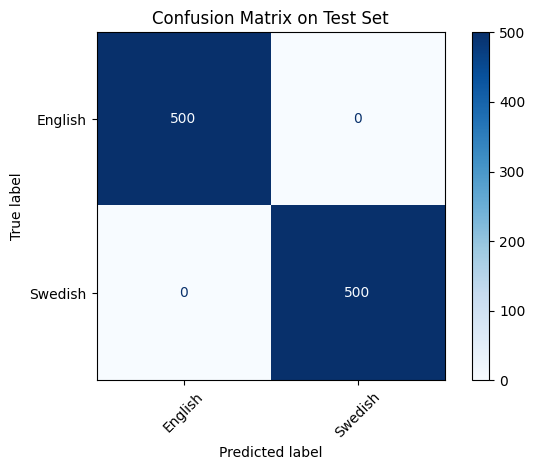

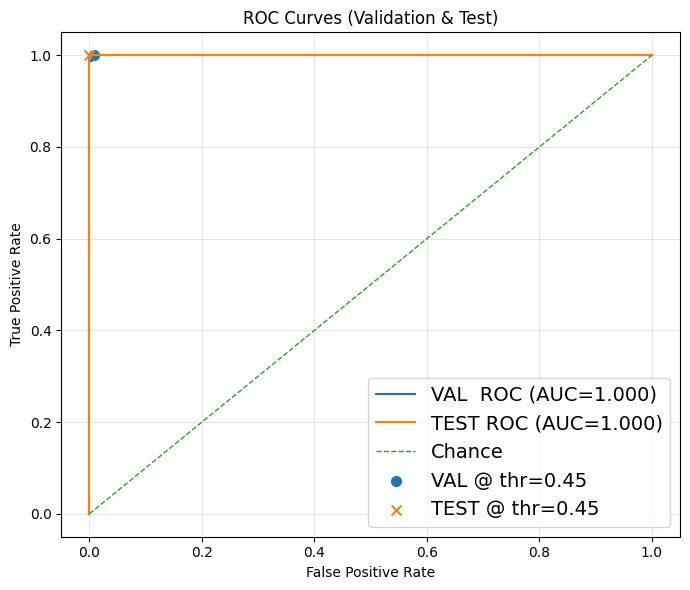

<Figure size 640x480 with 0 Axes>

✅ All confusion matrices sum to 200% (row-normalized).


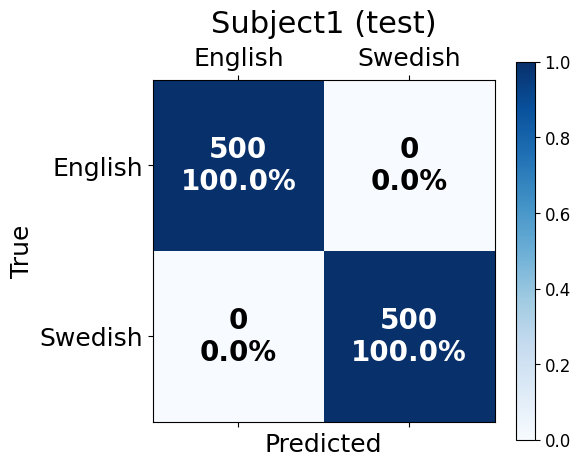

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model4_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_1_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])#lv-mae 128w and 128 embeddings size

# Example - use if you need cm format with large numbers and %:
cms1 = []
cms1.append(confusion_matrix(y_c, (prob_test >= best_thr).astype(int), labels=[0, 1]))
create_image_with_multiple_binary_confusion_matrices(cms=cms1,captions=None,n_cols=1,
                    class_names=["English", "Swedish"],color_map='Blues')

#### 40 ms, k = 1, 20 ms calib (10 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (750, 40, 32, 32, 1)
 x[1] shape is (750, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 750, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (1500, 40, 32, 32, 1))
((500, 1), (500, 1), (1500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (1500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...

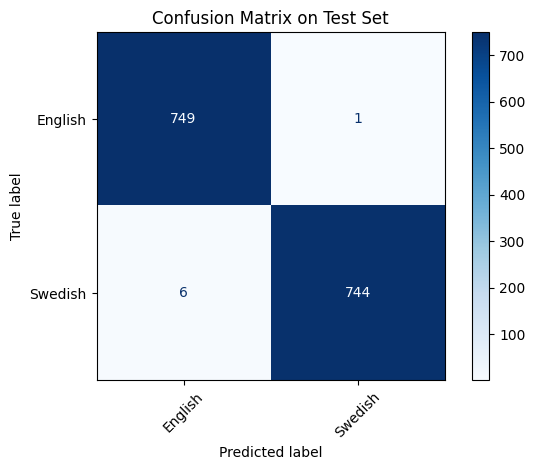

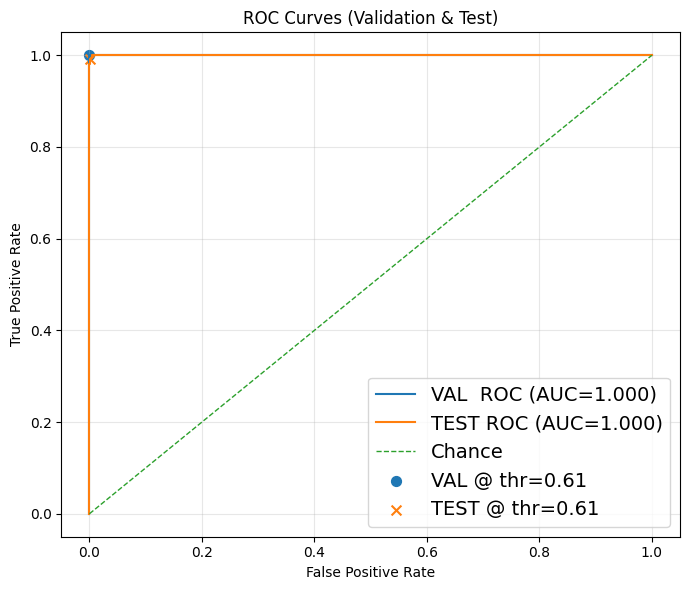

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model4_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_1_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1000, 40, 32, 32, 1)
 x[1] shape is (1000, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 1000, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (2000, 40, 32, 32, 1))
((300, 1), (200, 1), (2000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (2000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (2000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

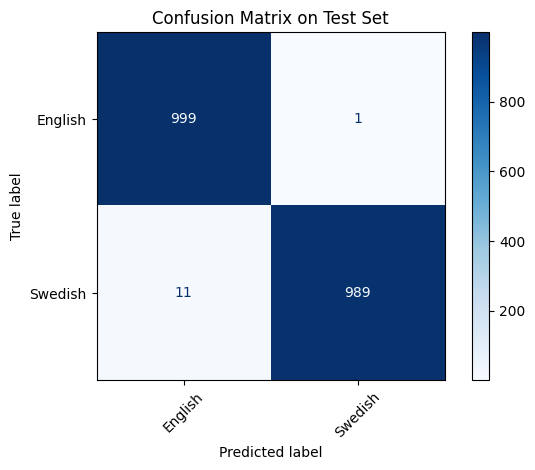

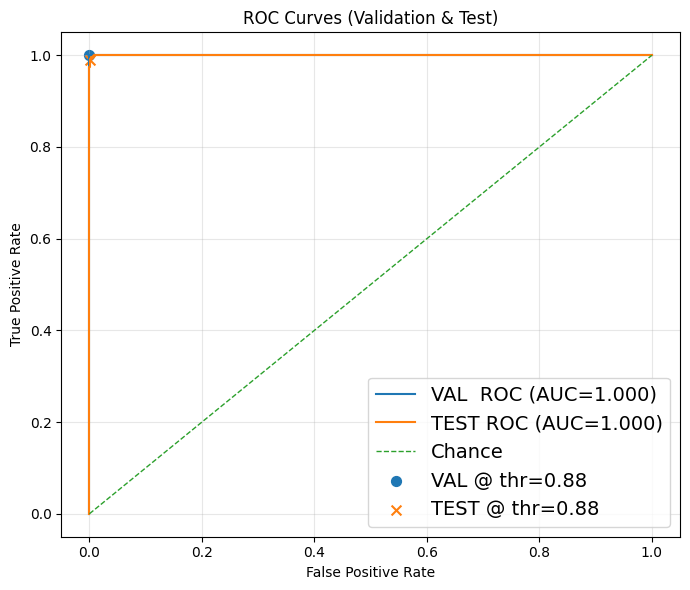

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model4_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_1_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X2

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

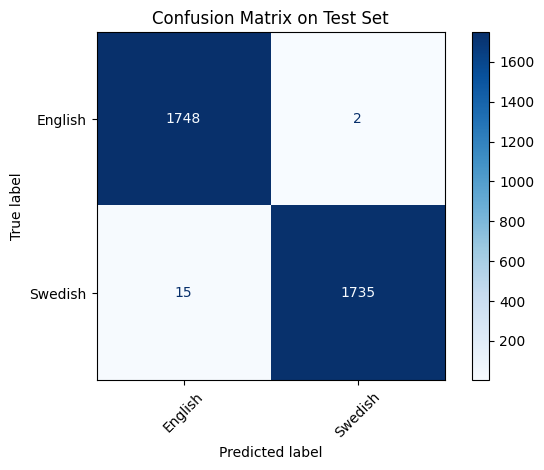

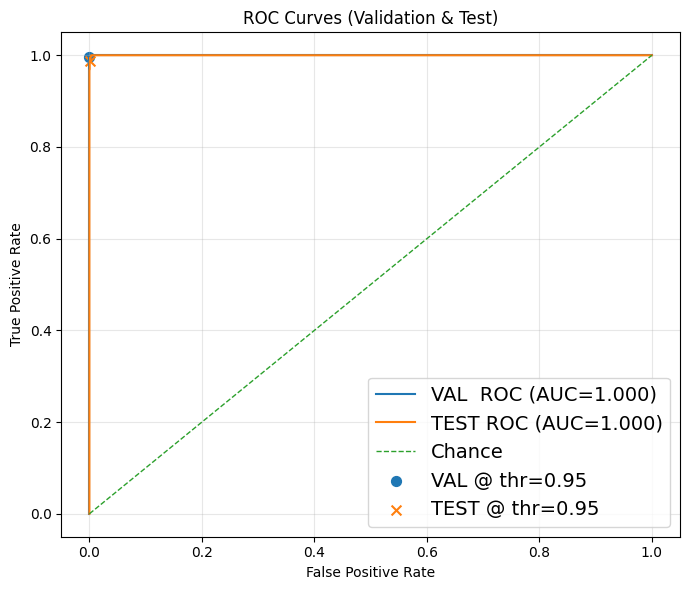

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model5_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_2_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 20 ms calib (100 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

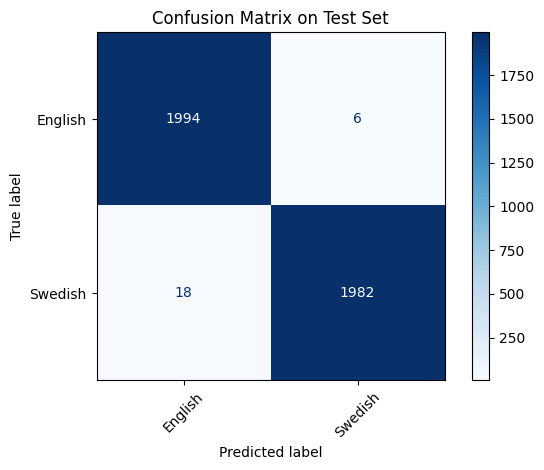

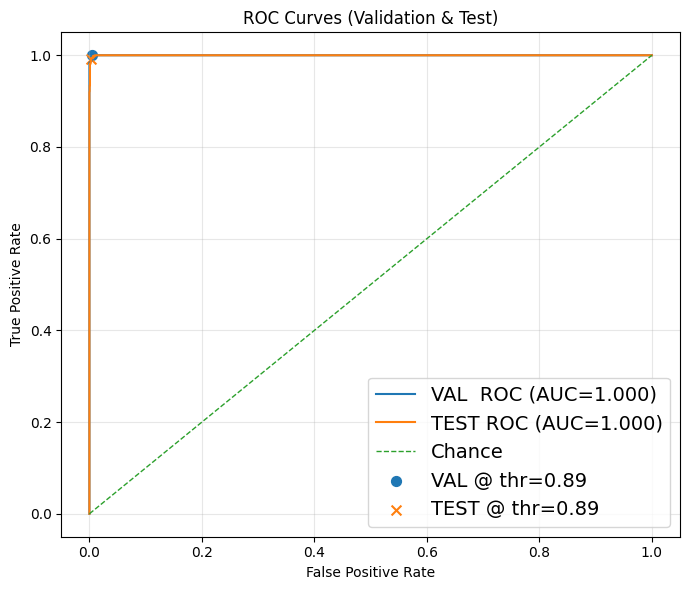

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model5_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_2_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

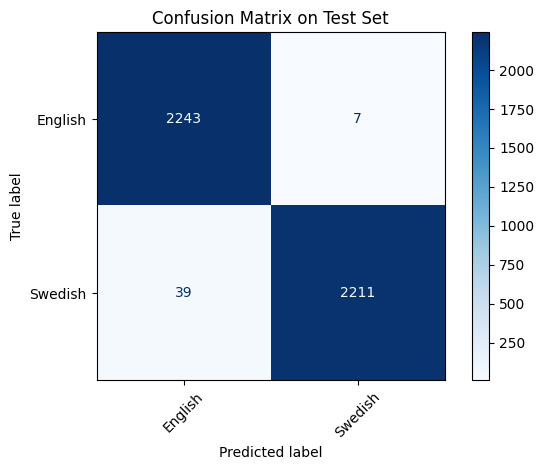

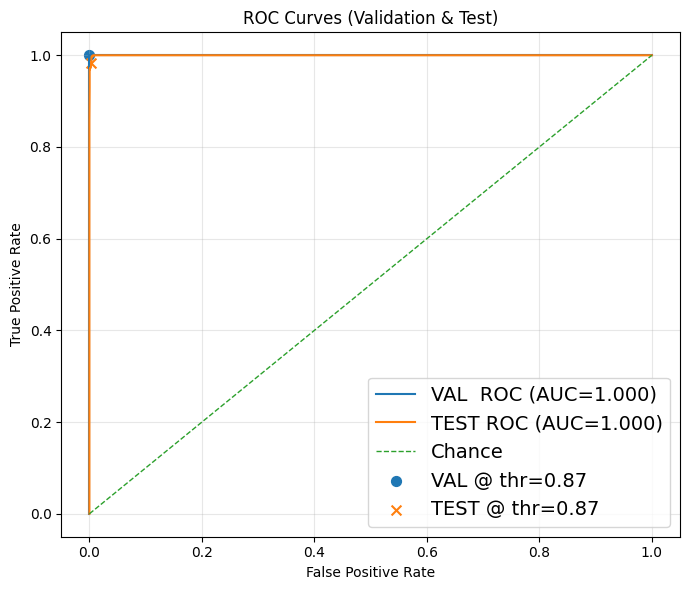

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model5_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
            test_2_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, roc_curve)

y_pred = (prob_test >= best_thr).astype(int)
test_auc = roc_auc_score(y_c, prob_test)
test_acc = accuracy_score(y_c, y_pred)

print(f"[XGB] TEST: AUC={test_auc:.4f} | ACC={test_acc:.4f}")

#print(classification_report(y_c, y_pred, target_names=class_names_list))

# Confusion matrix
cm = confusion_matrix(y_c, y_pred, labels=[0, 1])
cm

[XGB] TEST: AUC=0.9999 | ACC=0.9898


array([[2243,    7],
       [  39, 2211]])

## X3

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

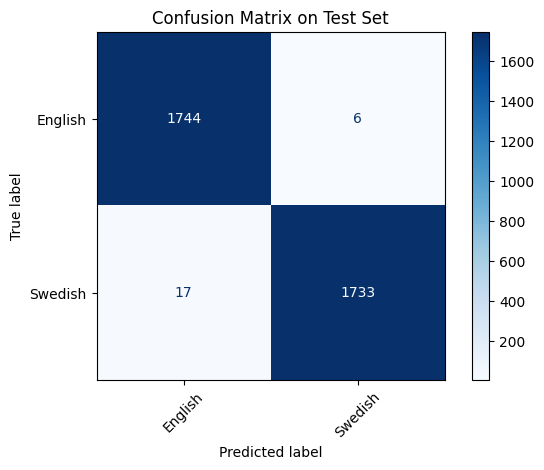

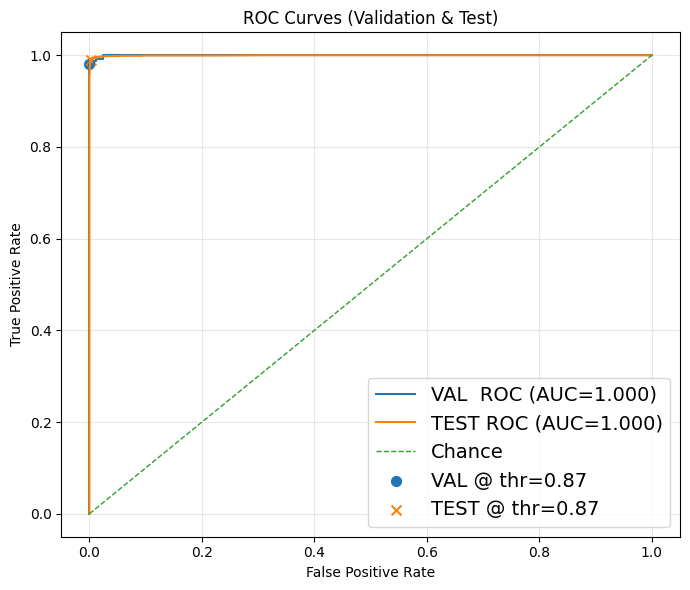

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_3_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 20 ms calib (10 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

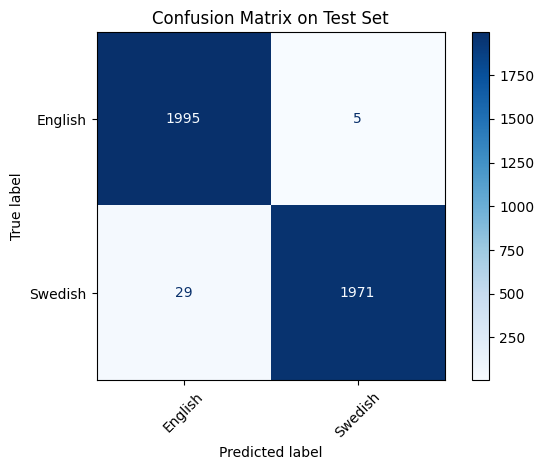

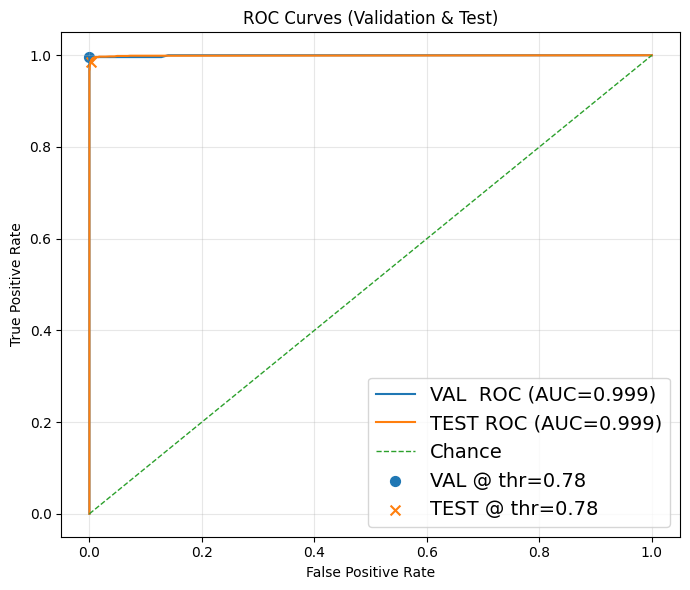

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_3_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

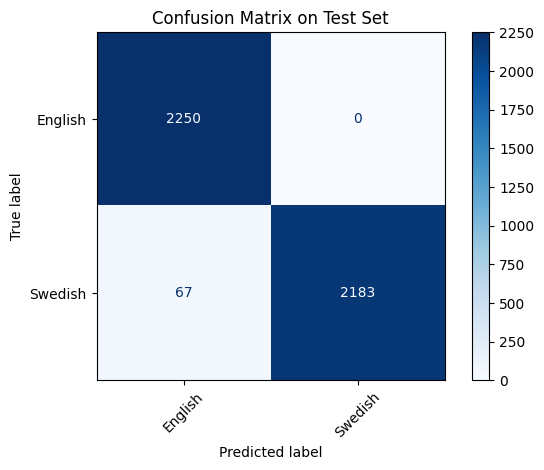

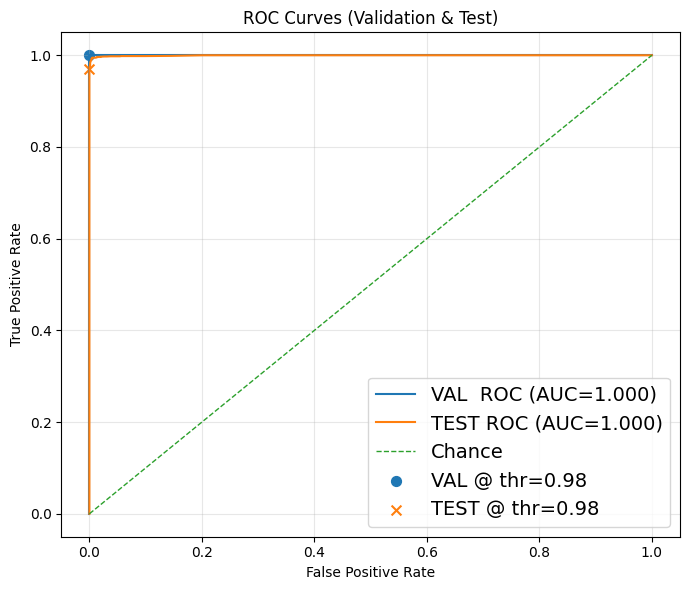

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_3_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X4

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

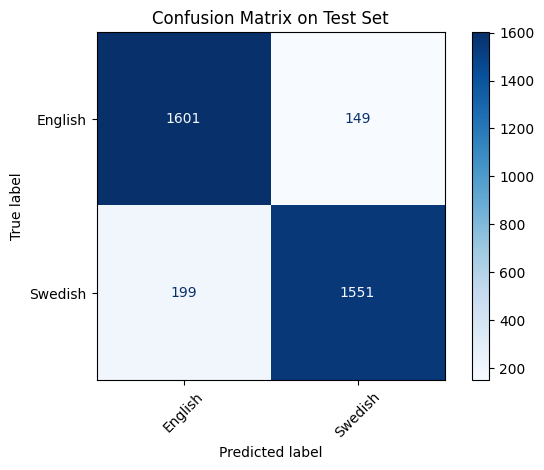

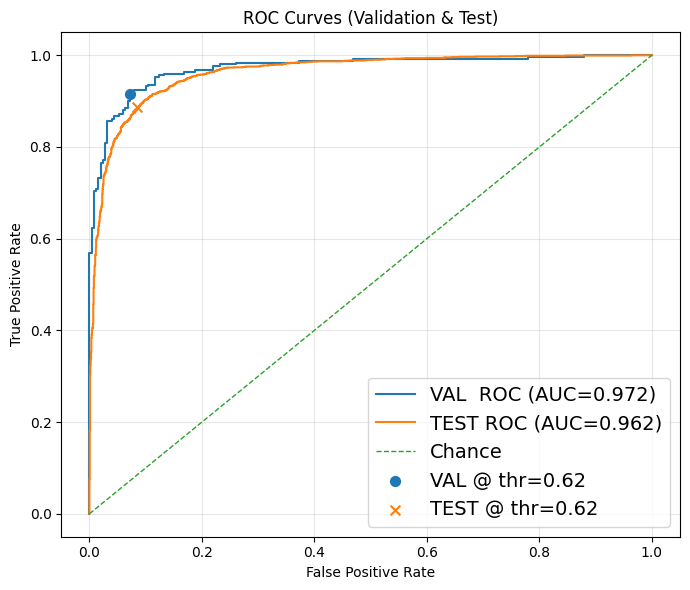

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_4_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 20 ms calib (10 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

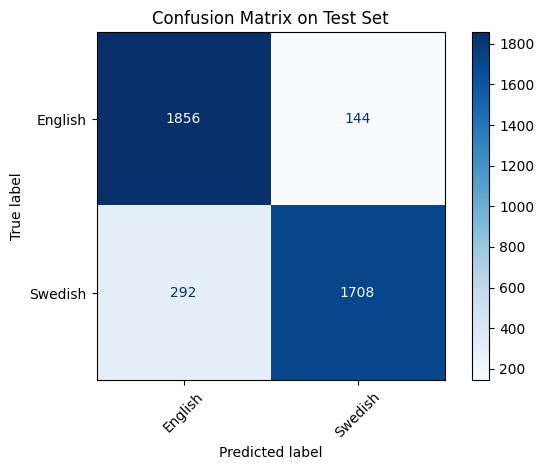

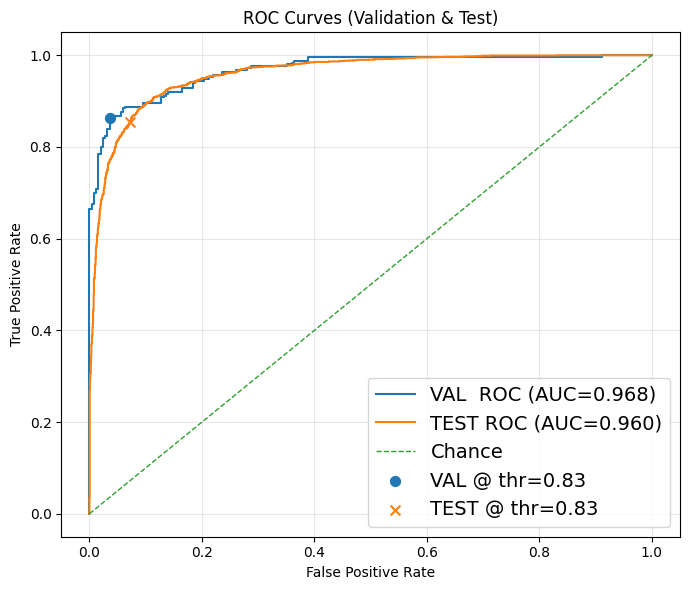

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_4_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

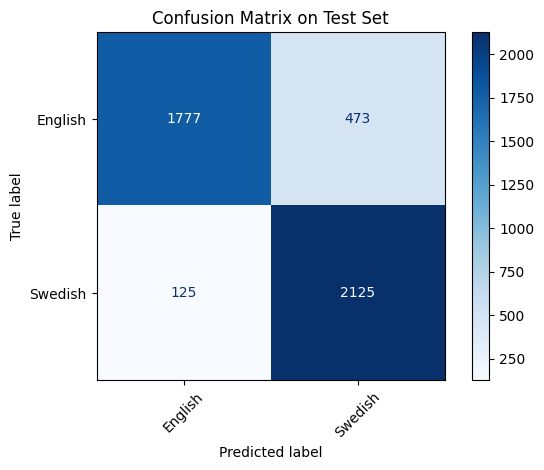

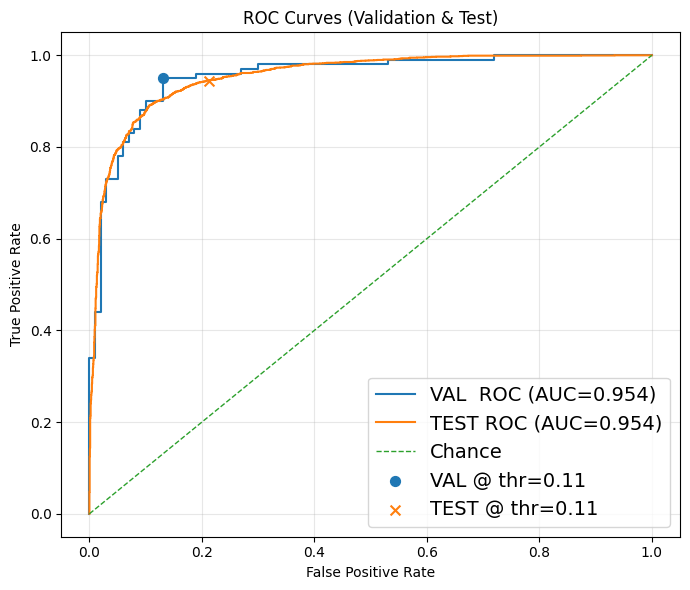

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_4_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X5

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

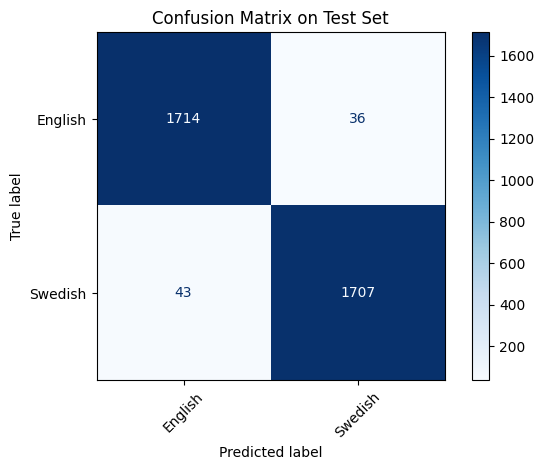

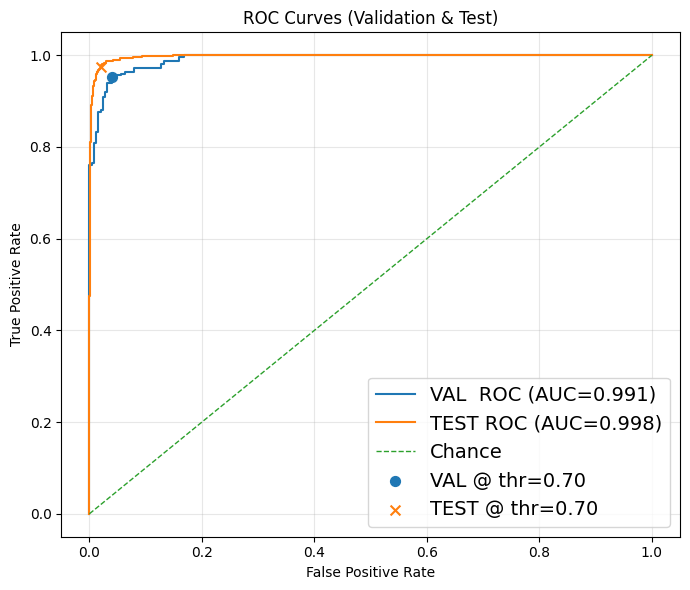

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_5_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 20 ms calib (10 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

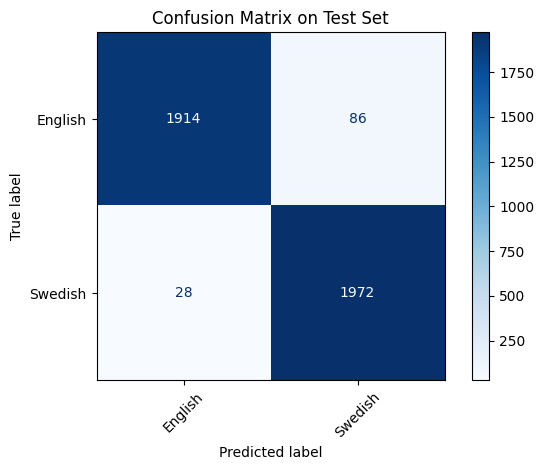

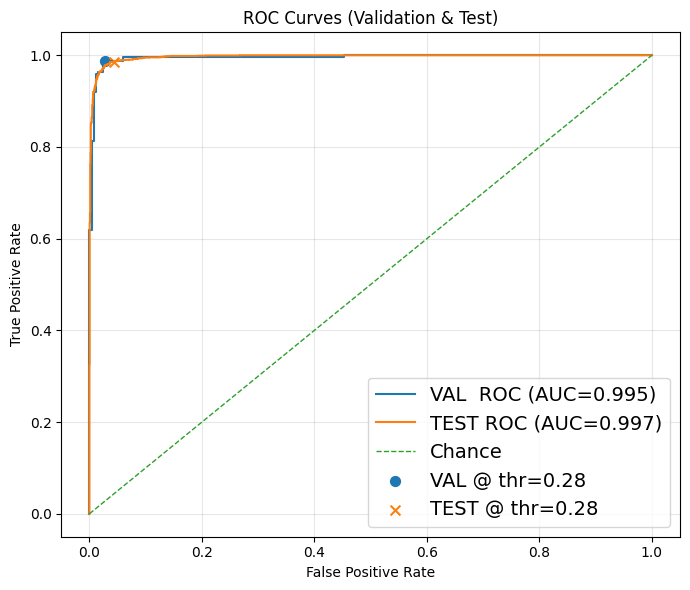

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_5_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

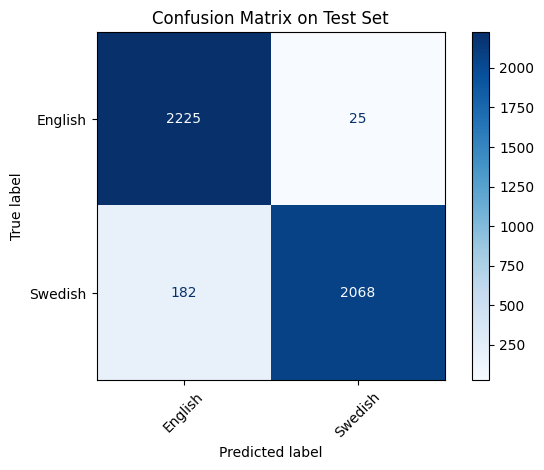

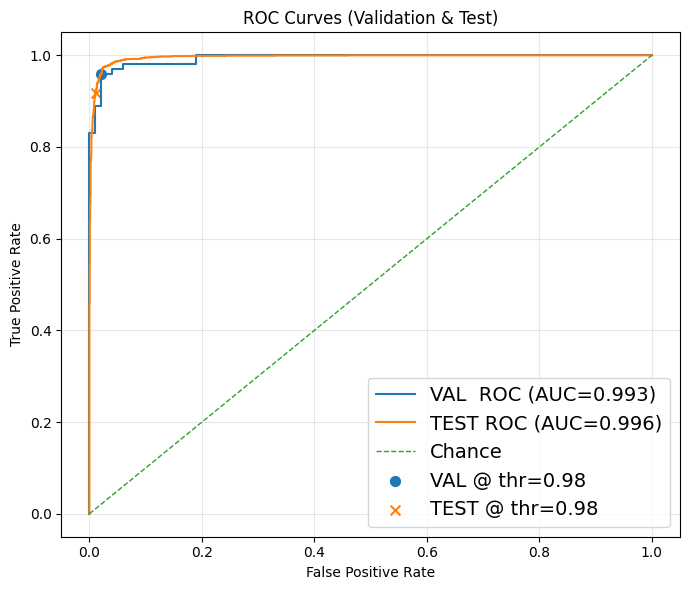

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_5_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X6

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (4250, 40, 32, 32, 1)
 x[1] shape is (4250, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 4250, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (8500, 40, 32, 32, 1))
((1000, 1), (500, 1), (8500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (8500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (8500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

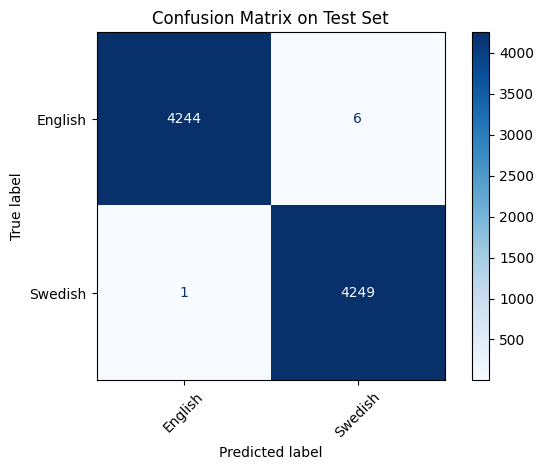

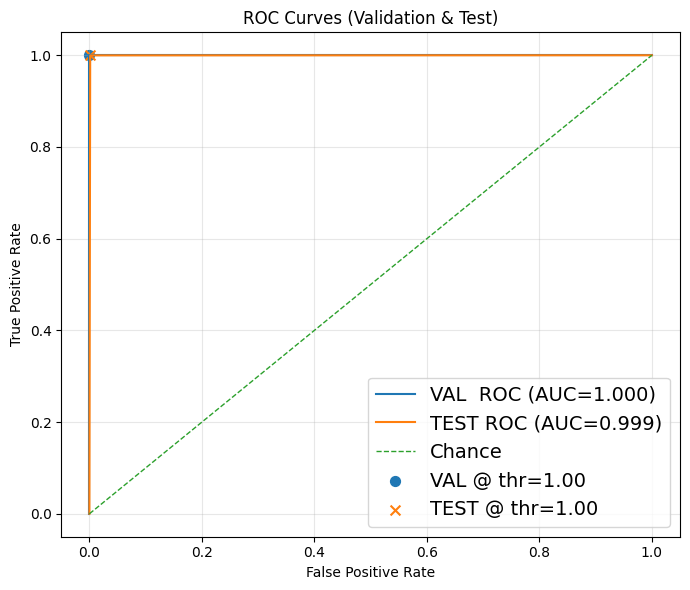

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model2_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_6_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, 20ms calib (10ms/10ms=tarin/val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (4500, 40, 32, 32, 1)
 x[1] shape is (4500, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 4500, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (9000, 40, 32, 32, 1))
((500, 1), (500, 1), (9000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (9000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (9000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

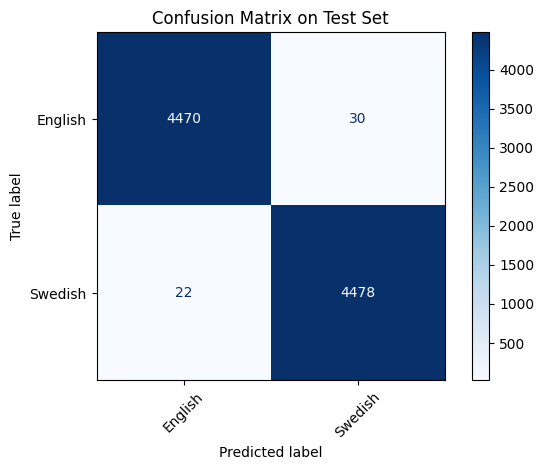

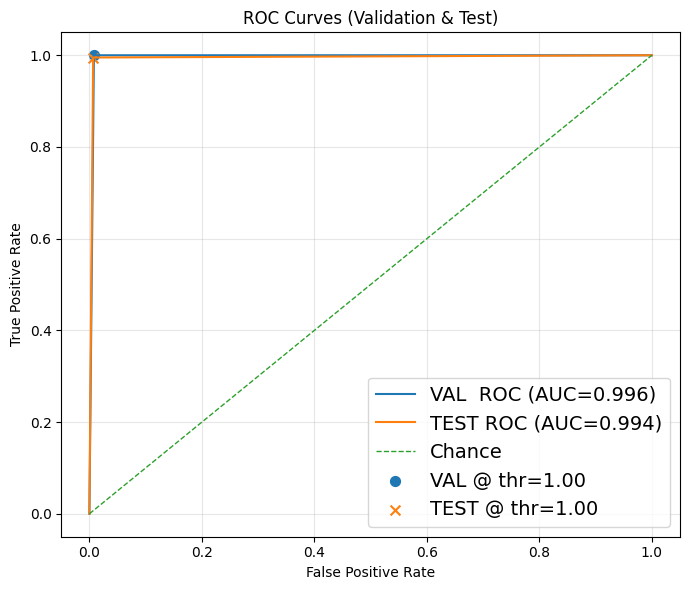

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model2_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_6_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40ms, 10ms in calibration (150/100 chunks = train/val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (4750, 40, 32, 32, 1)
 x[1] shape is (4750, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 4750, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (9500, 40, 32, 32, 1))
((300, 1), (200, 1), (9500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (9500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (9500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

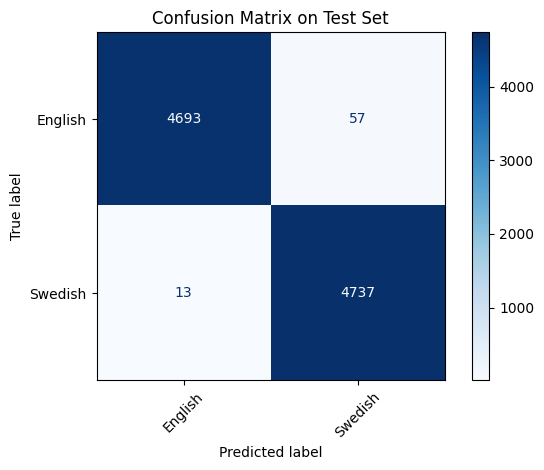

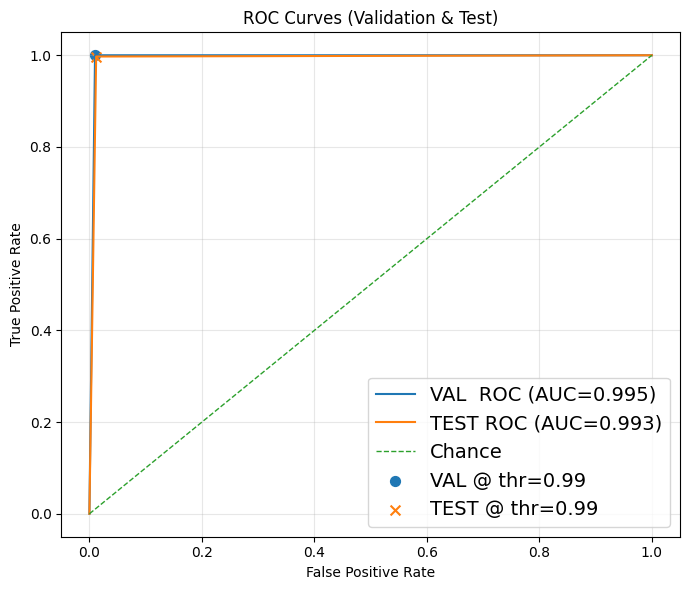

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model2_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_6_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X7

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

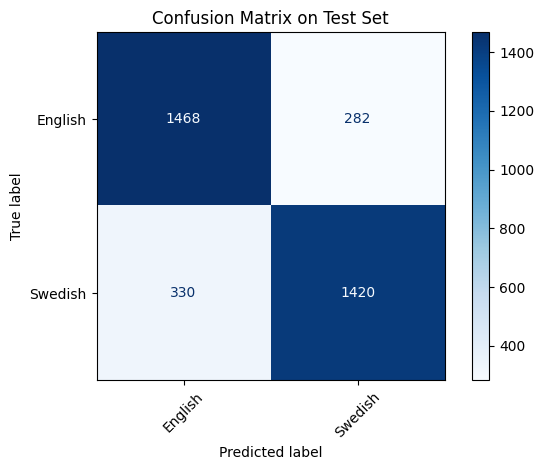

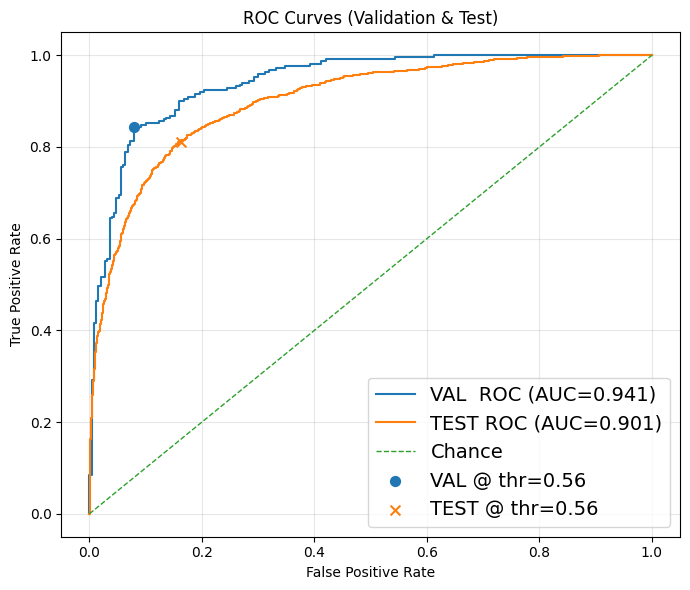

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model8_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_7_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 20 ms calib (10 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

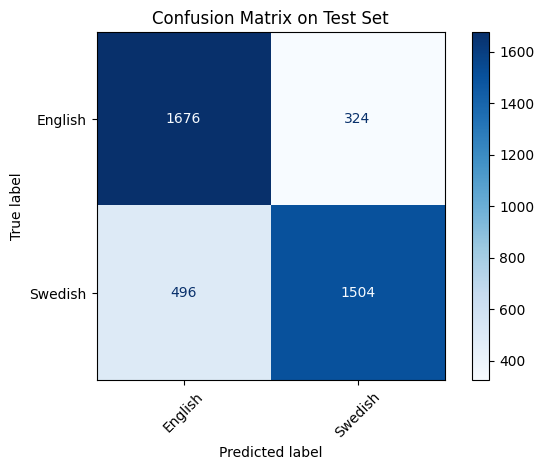

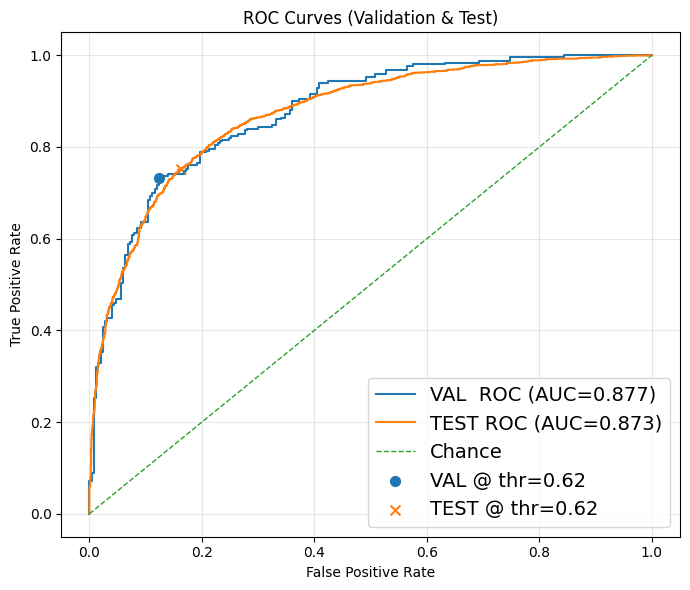

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model8_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
    test_7_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

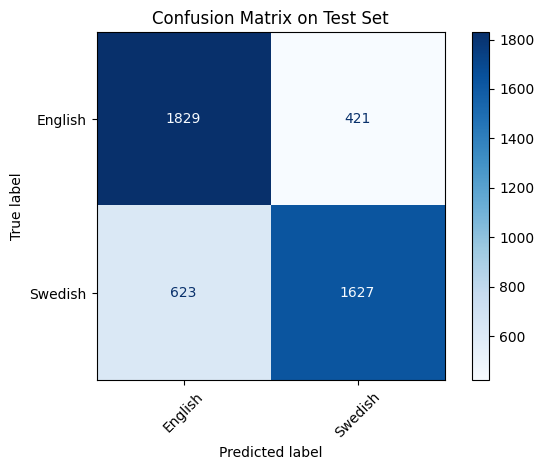

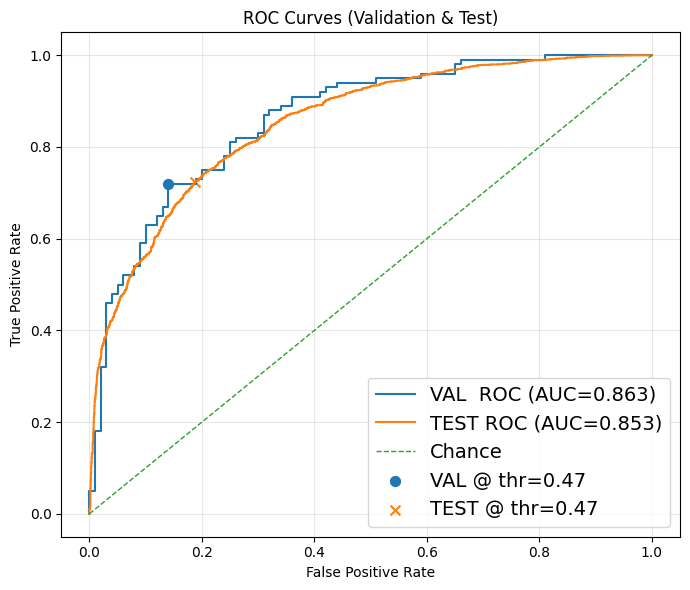

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model8_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_7_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X8

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

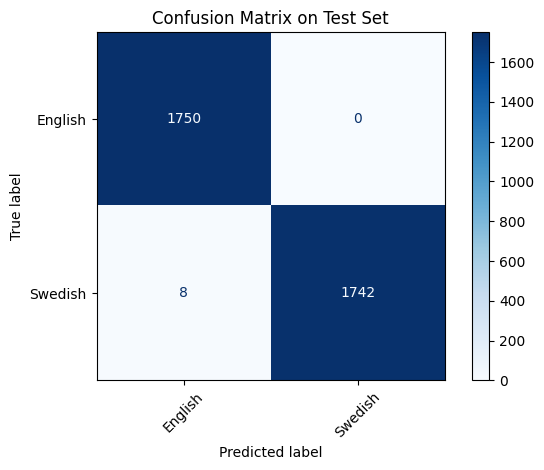

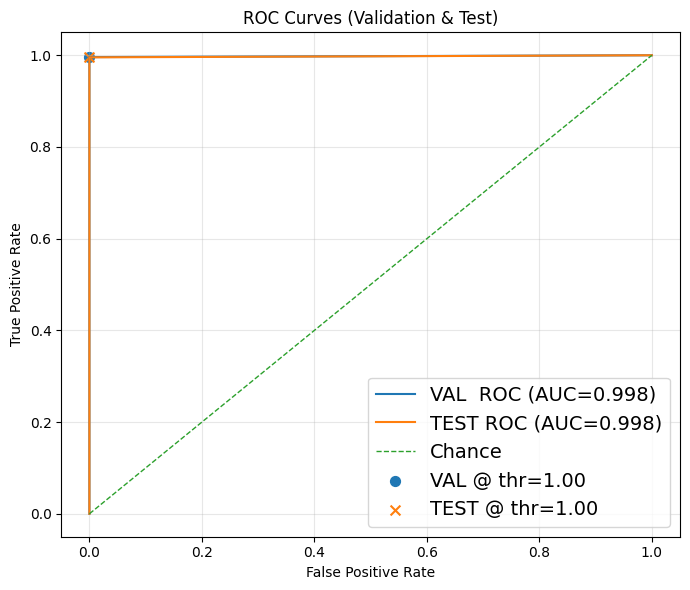

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model9_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_8_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 20 ms calib (10 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

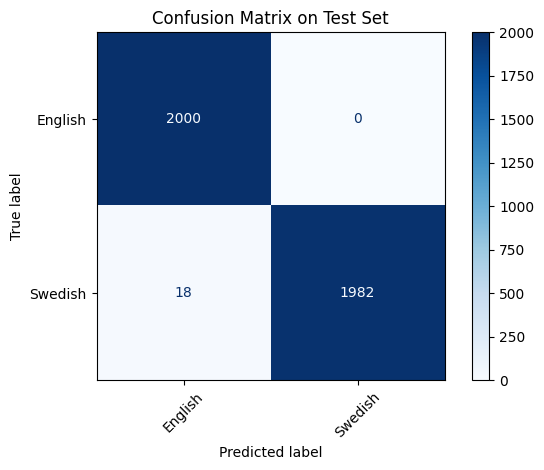

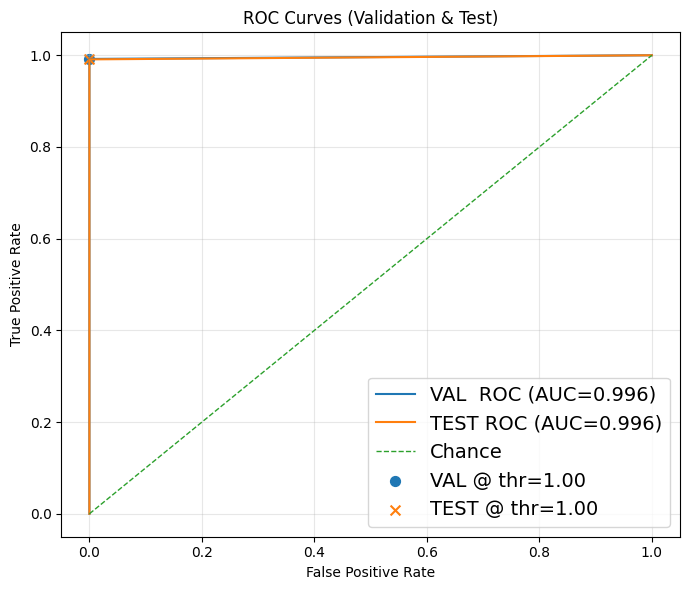

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model9_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_8_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

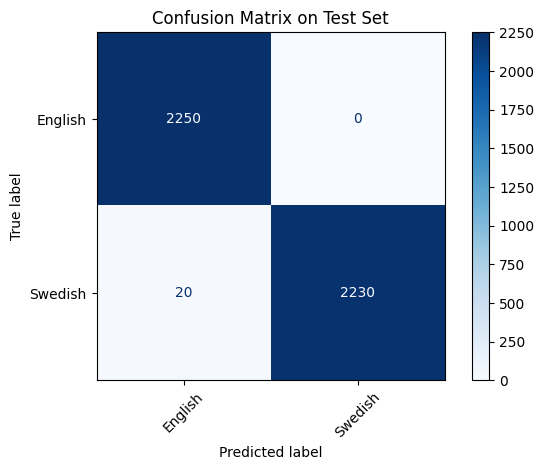

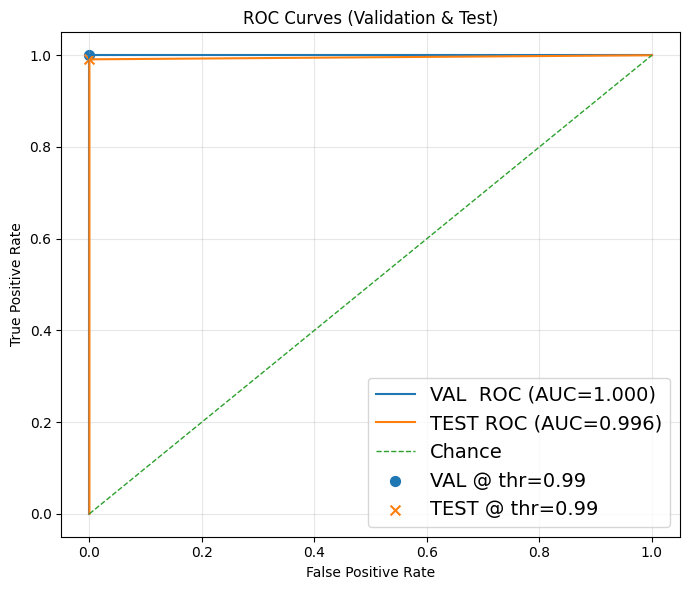

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model9_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_8_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X9

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

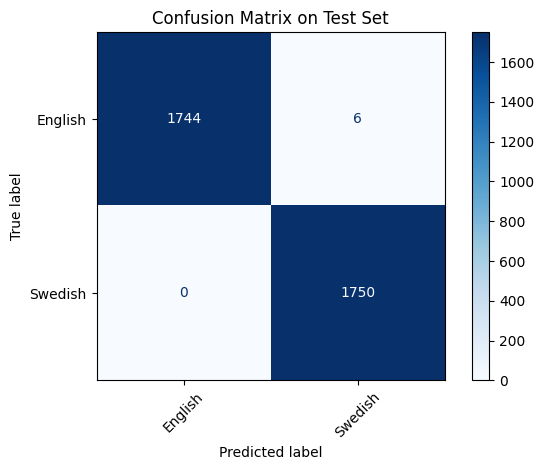

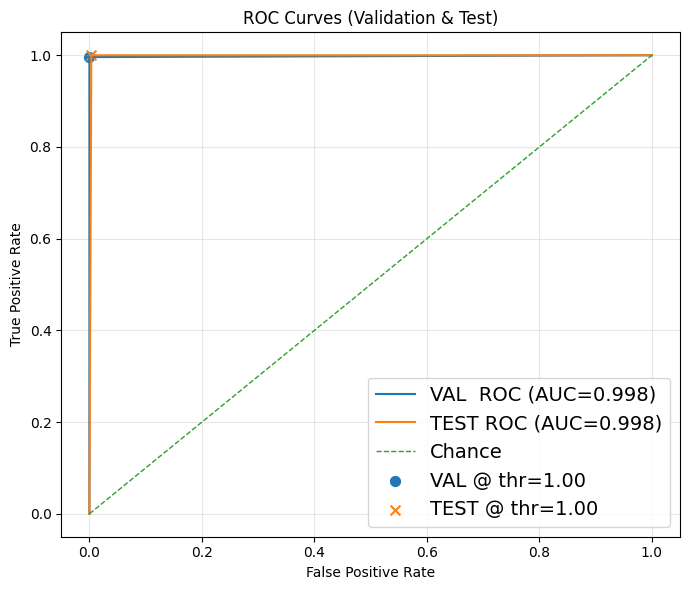

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_9_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 20 ms calib (10 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

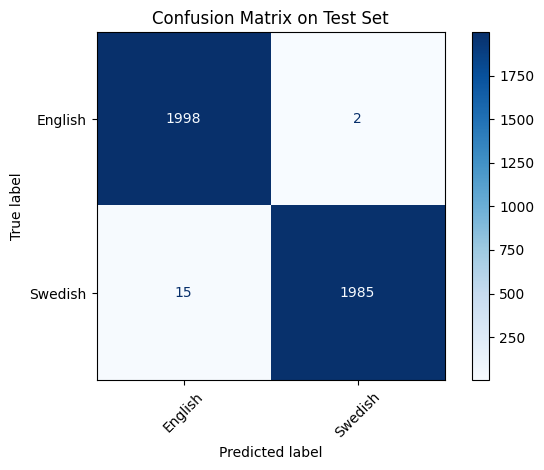

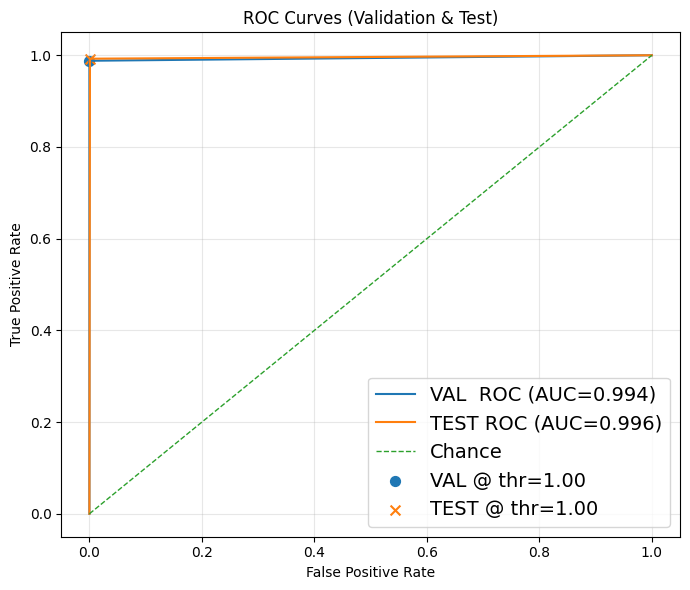

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_9_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

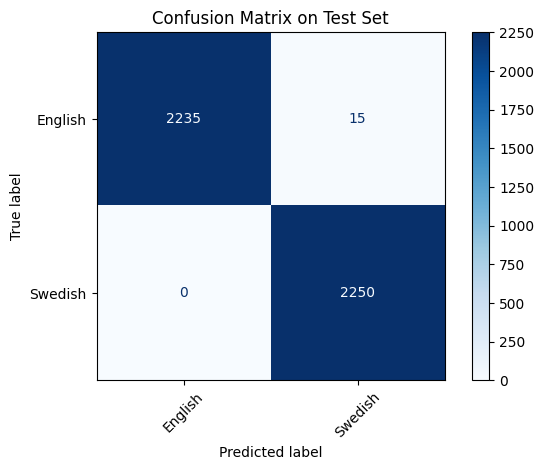

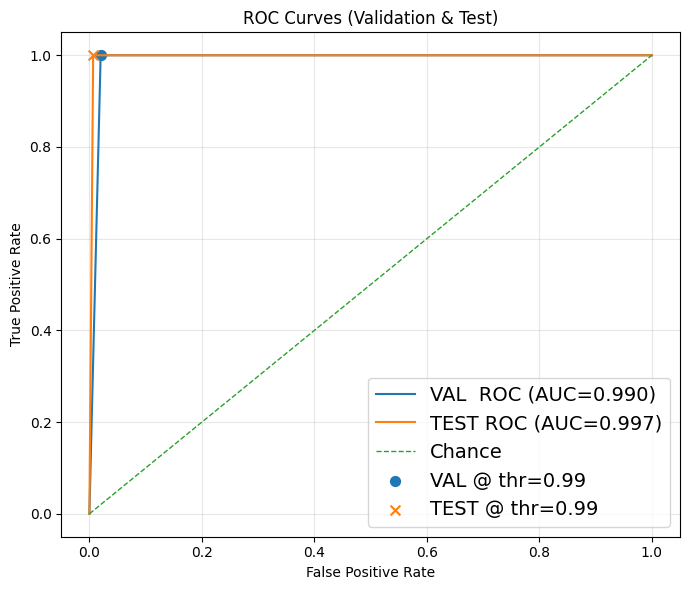

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_9_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X10

#### 40 ms (k = 1)
- LV-MAE trained for 30 epoches, subj 10 excluded, trined on on Broca's BCI yes vs no task data
- calibration: sequential from start+minmax on 30 ms calib (20 train, 10 val)
- evaluated on comprehension data


checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

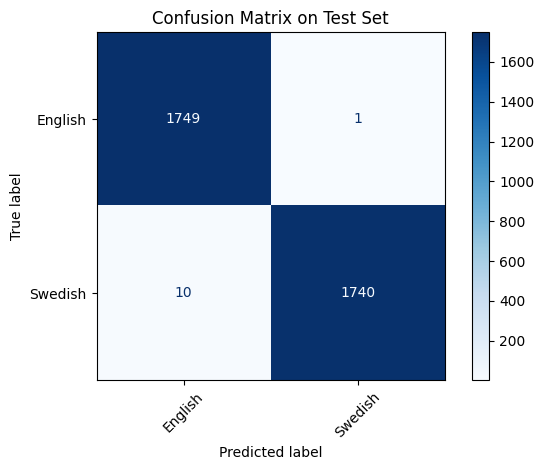

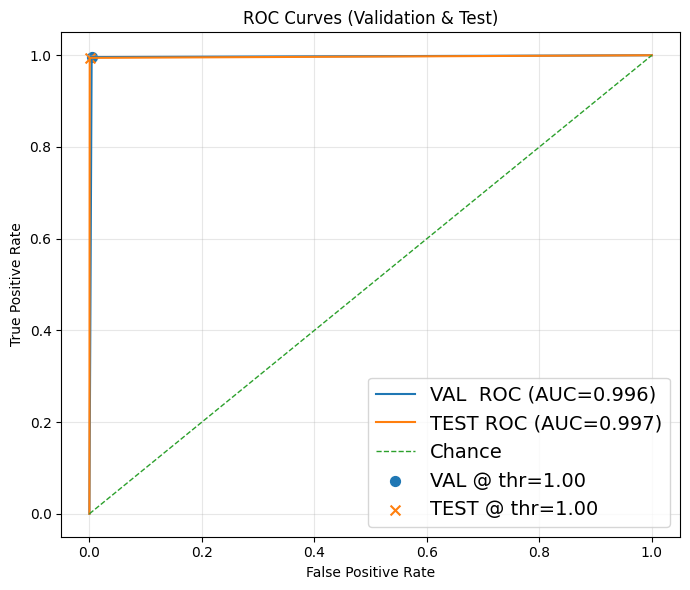

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
# pay attention to choose LV-MAE where the particular subject you test on is excluded from training
# in case the same subject oarticipated in "yes" vas "no" experiment.
# there are 9 LV-MAE models, mumber corresponds to excluded subject
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_10_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
#K=1 corresponds to 40 ms evaluation granularity, K tells us what about of 40-ms embedings to concatenate in the sliding window
 # 128w and 128

#### 1s (k=25)
- sliding window aggregation
- target number of evaluation chunks is N-k+1
where N is the number of original 40 ms chunks, so 9000 goes to be 8976

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=25): train (976, 3200), val (476, 3200), test (3476, 3200)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [0.00208795 0.00208795 0.9980123  0.9980123  

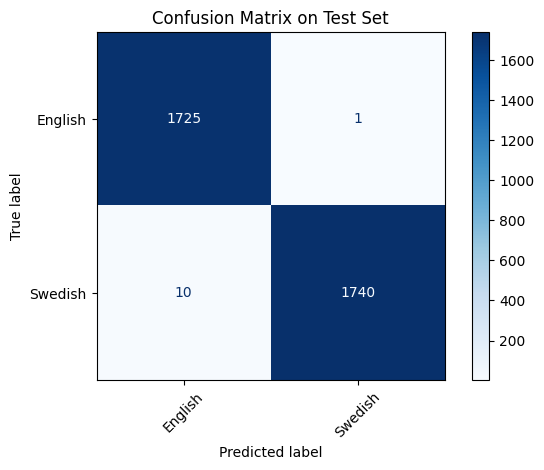

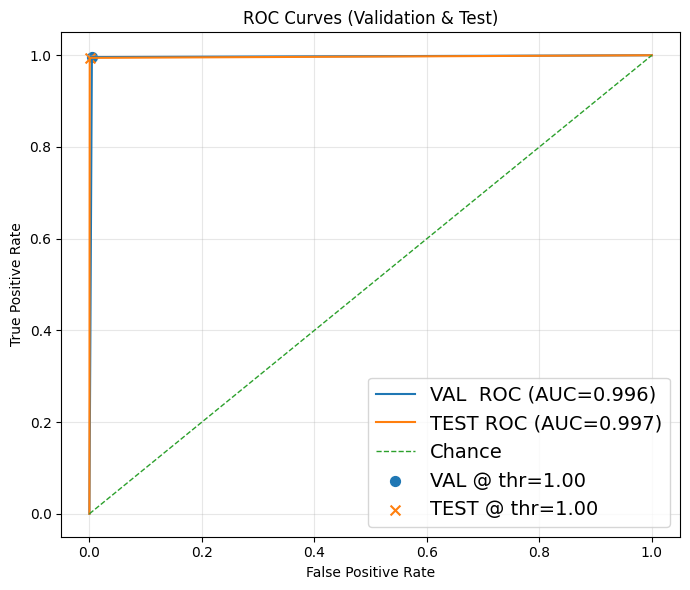

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1


clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_10_m_n_40ms, train_n=500, val_n=250, K = 25, class_names_list = ["English", "Swedish"])

#### 80 ms (k=2)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=2): train (999, 256), val (499, 256), test (3499, 256)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [0.00173498 0.00173498 0.99826849 0.99826849 0.99

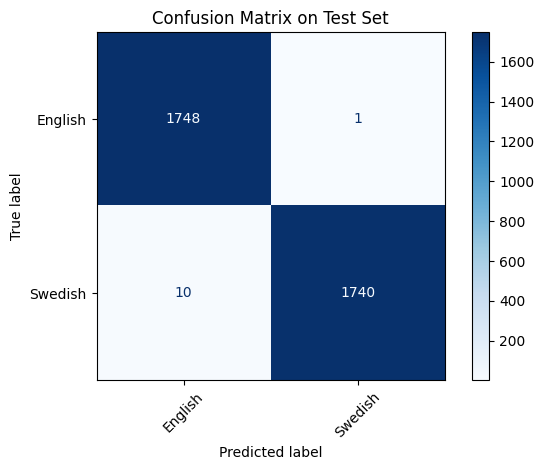

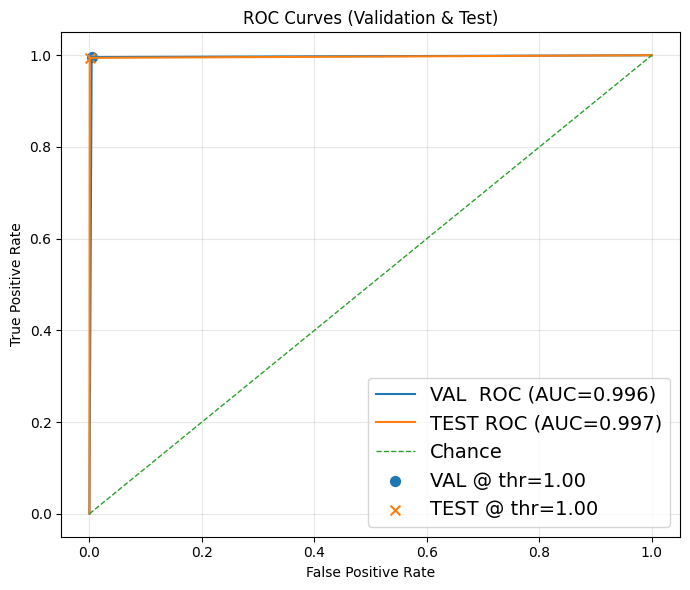

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_10_m_n_40ms, train_n=500, val_n=250, K = 2, class_names_list = ["English", "Swedish"])

#### 120 ms (k=3)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=3): train (998, 384), val (498, 384), test (3498, 384)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [0.00177799 0.00177799 0.80194044 0.99831021 0.99

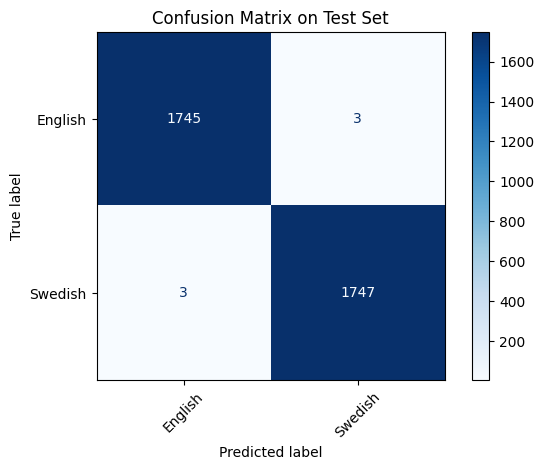

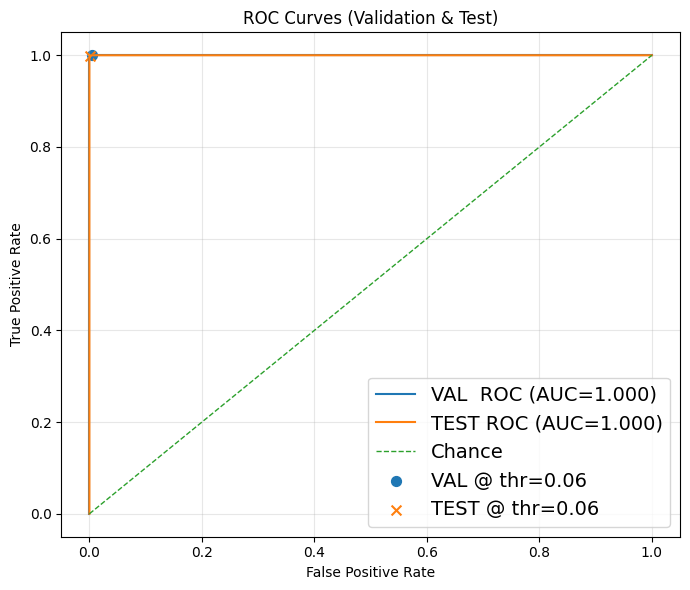

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_10_m_n_40ms, train_n=500, val_n=250, K = 3, class_names_list = ["English", "Swedish"])

#### 160 ms (k=4)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=4): train (997, 512), val (497, 512), test (3497, 512)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [0.00178072 0.00178072 0.92064005 0.99831092 0.99

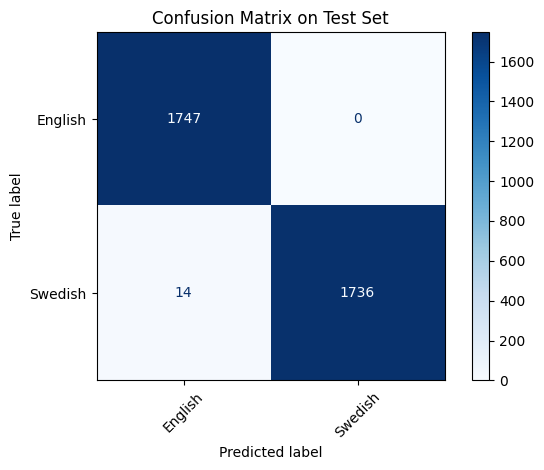

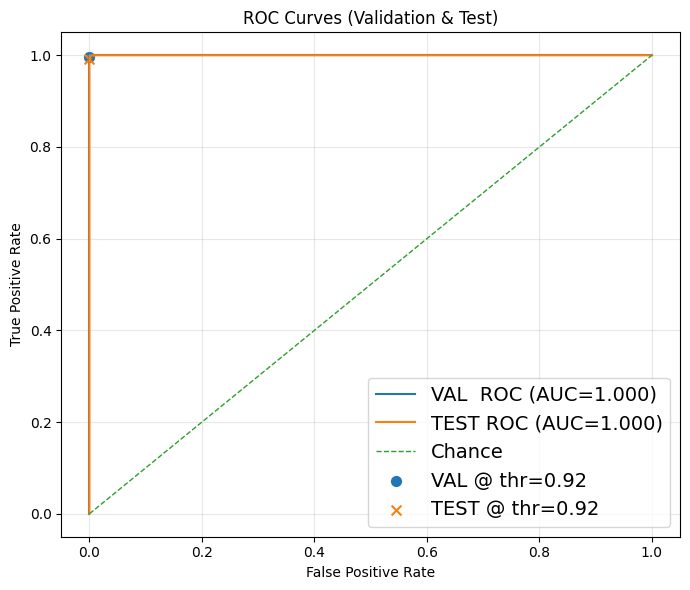

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_10_m_n_40ms, train_n=500, val_n=250, K = 4, class_names_list = ["English", "Swedish"])

#### 40 ms inputs, 20ms calib (10/10 ms=train/val of XGBoost)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

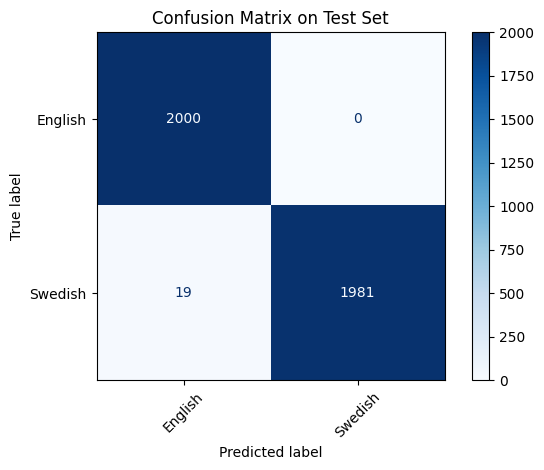

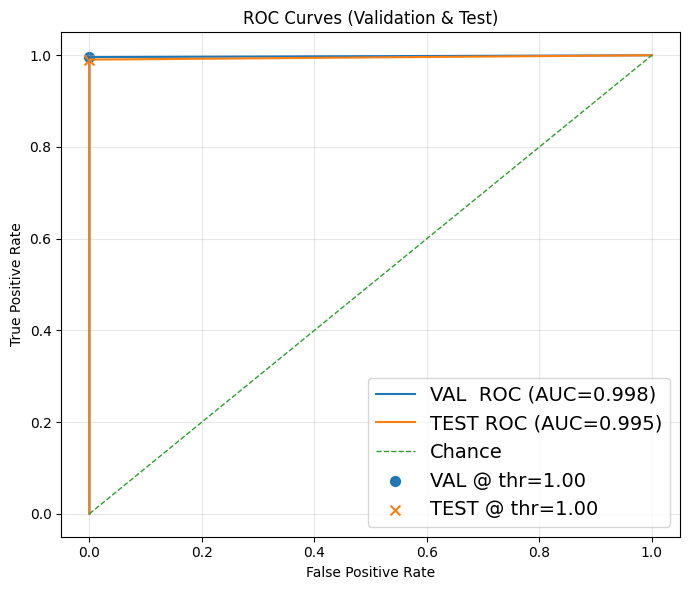

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_10_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])

#### 40 ms, k = 1, 10 ms calib (10 train + val: 150 chunks in train and 100 in val),
- each chunk 40ms chunks in val

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

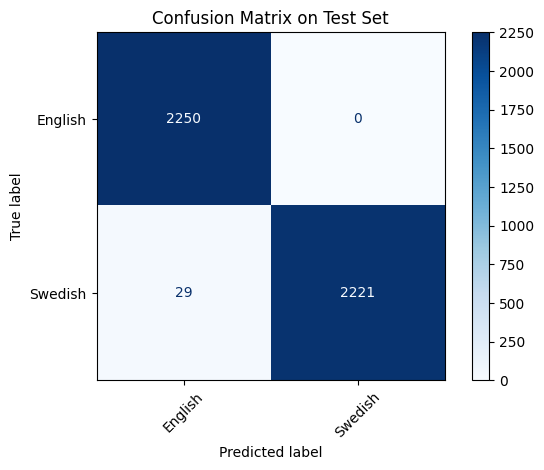

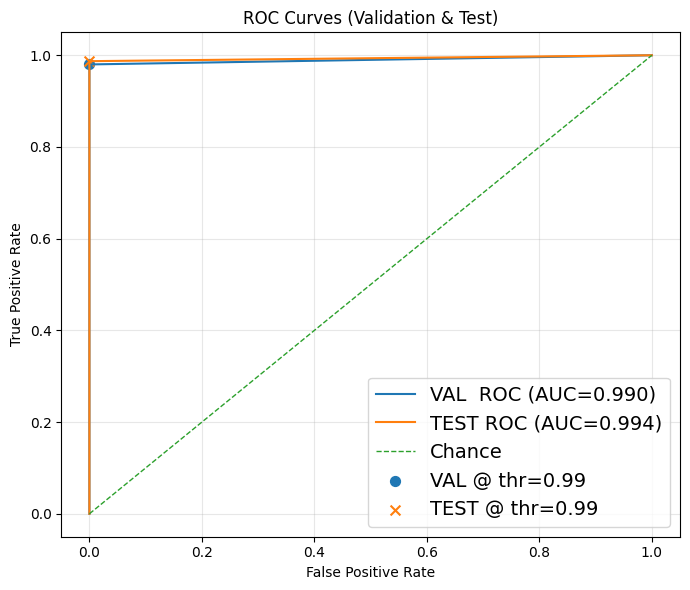

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_10_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])

## X11

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

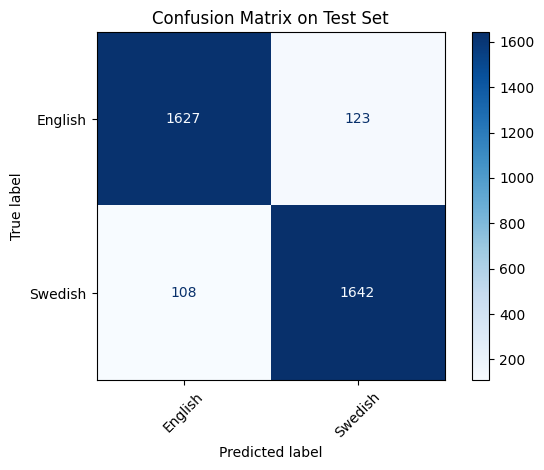

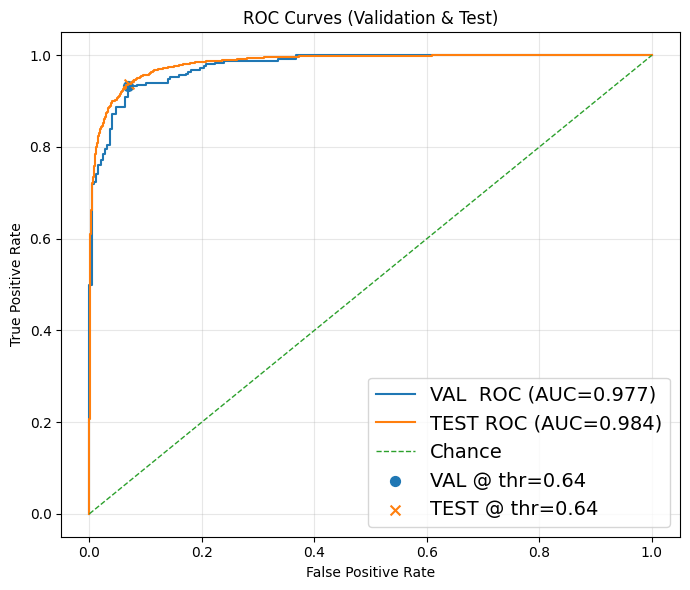

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_11_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

#### 1s (k=25)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=25): train (976, 3200), val (476, 3200), test (3476, 3200)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [3.36707482e-04 3.15952644e-03 9.10576761e-01

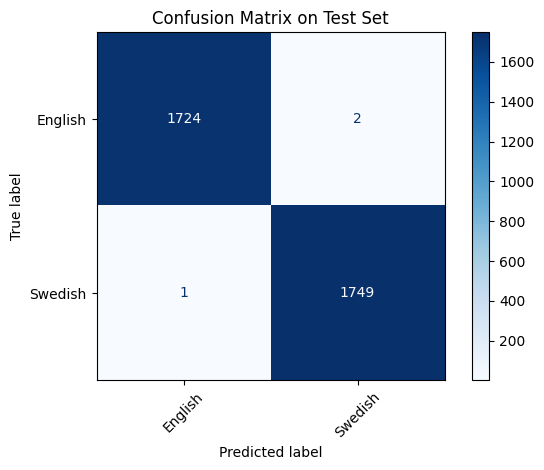

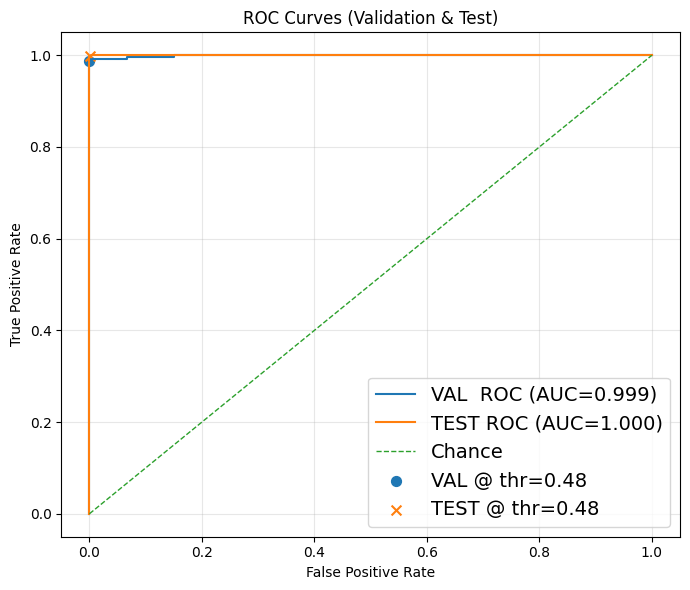

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_11_m_n_40ms, train_n=500, val_n=250, K = 25, class_names_list = ["English", "Swedish"])

#### 80 ms (k=2)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=2): train (999, 256), val (499, 256), test (3499, 256)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [3.17654521e-05 4.50934051e-04 7.53055811e-01 9.9

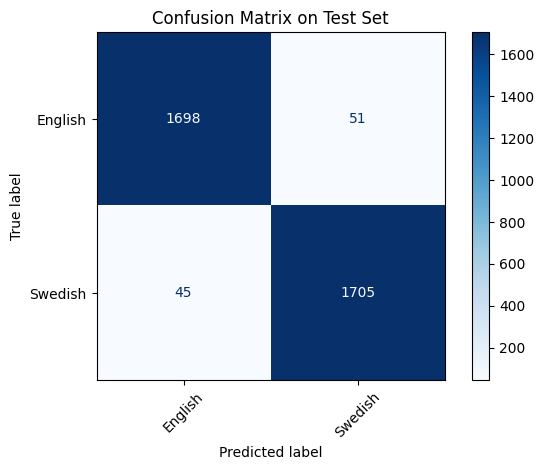

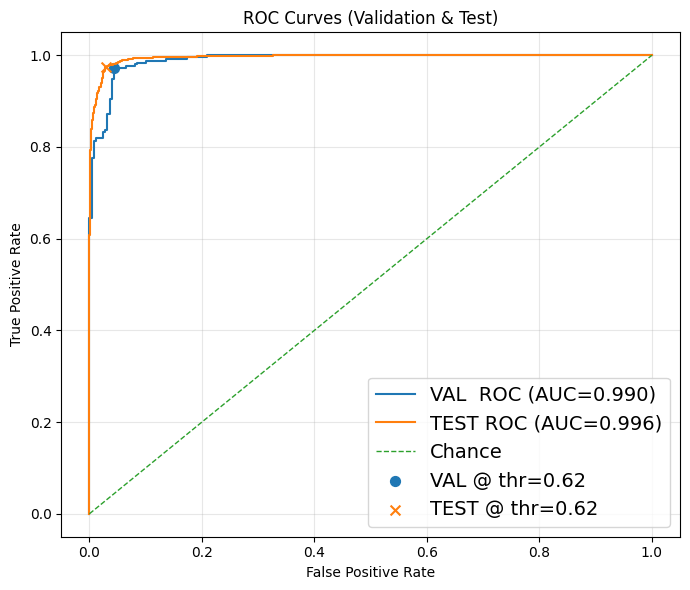

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_11_m_n_40ms, train_n=500, val_n=250, K = 2, class_names_list = ["English", "Swedish"])

#### 120 ms (k=3)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=3): train (998, 384), val (498, 384), test (3498, 384)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [5.34402425e-05 3.13292039e-04 8.70160580e-01 9.9

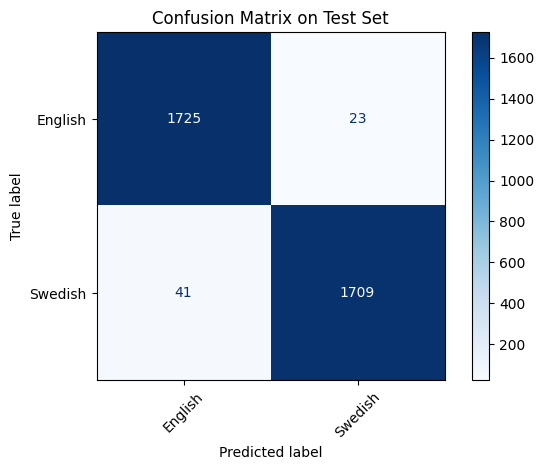

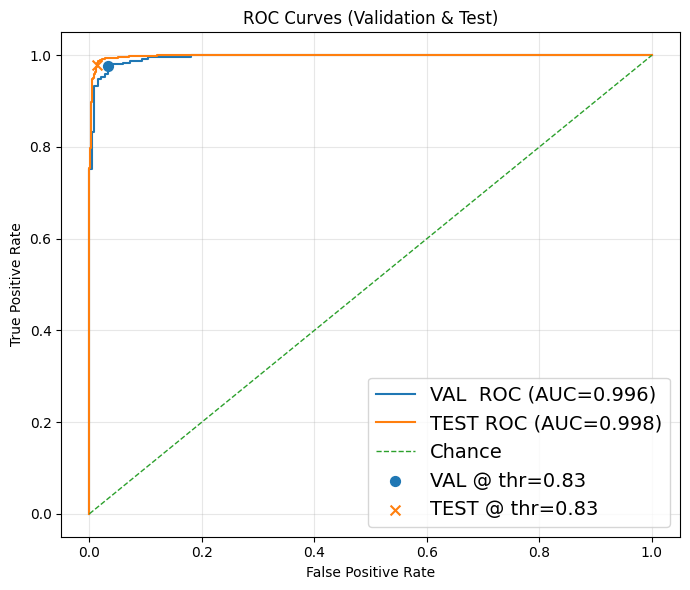

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_11_m_n_40ms, train_n=500, val_n=250, K = 3, class_names_list = ["English", "Swedish"])

#### 160 ms (k=4)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=4): train (997, 512), val (497, 512), test (3497, 512)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [1.01673933e-04 5.58960543e-04 7.43387997e-01 9.9

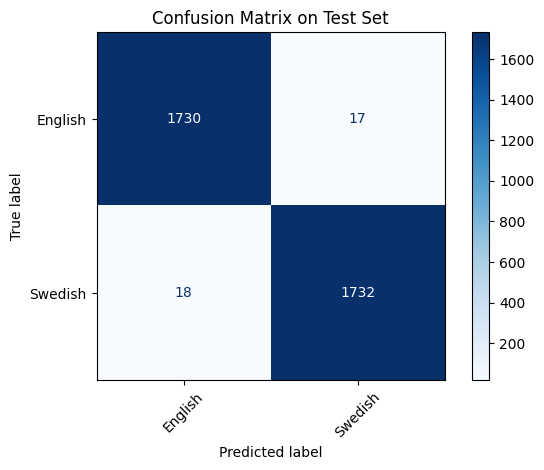

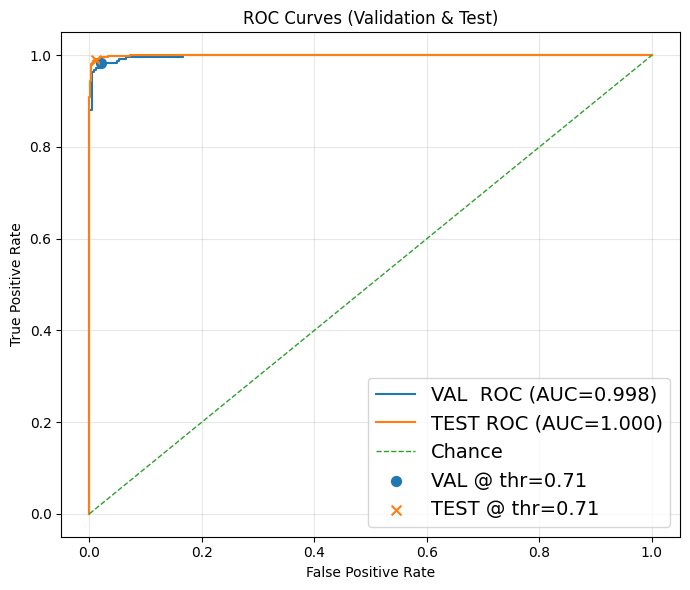

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_11_m_n_40ms, train_n=500, val_n=250, K = 4, class_names_list = ["English", "Swedish"])

### 40 ms, 20 ms calib (10ms train/ 10 ms val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

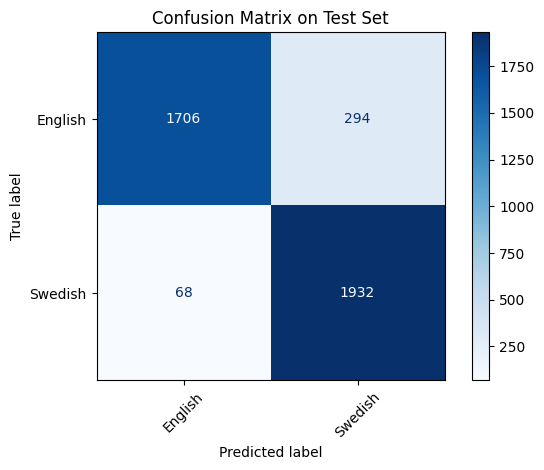

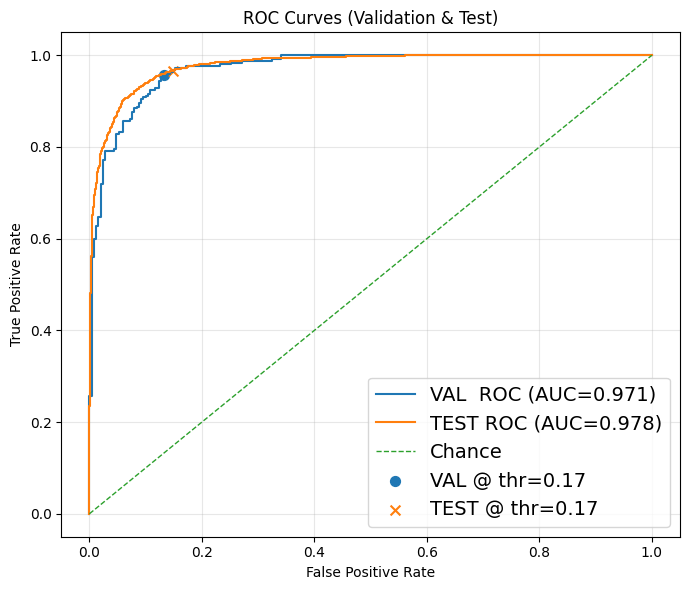

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_11_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

### 40 ms (10ms train+val 150+100 chunks)

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

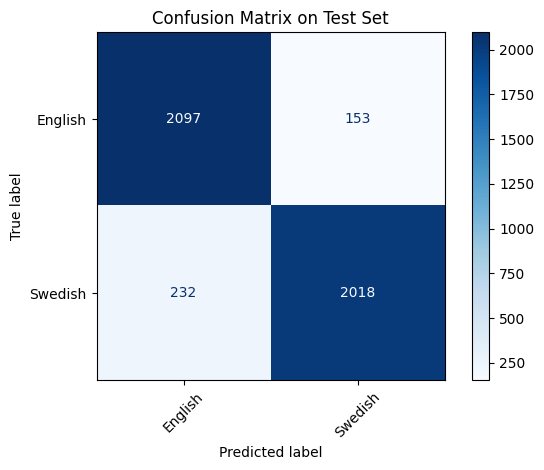

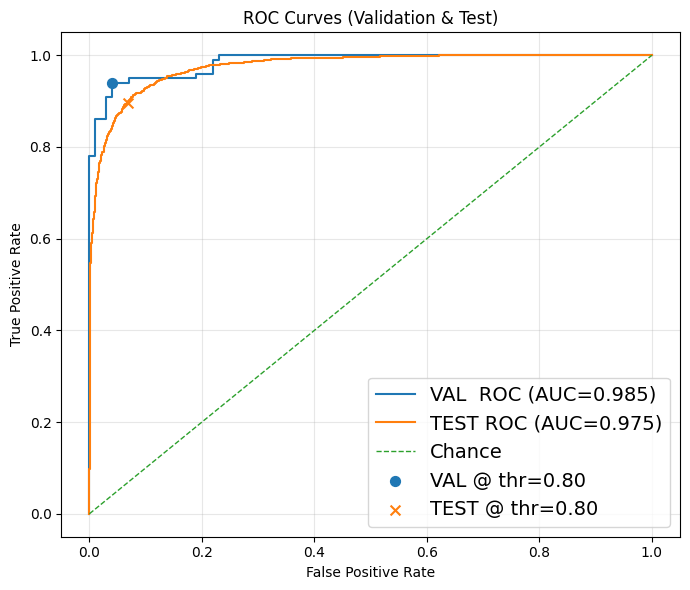

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_11_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])
# 128w and 128 embeddings size

## X12

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

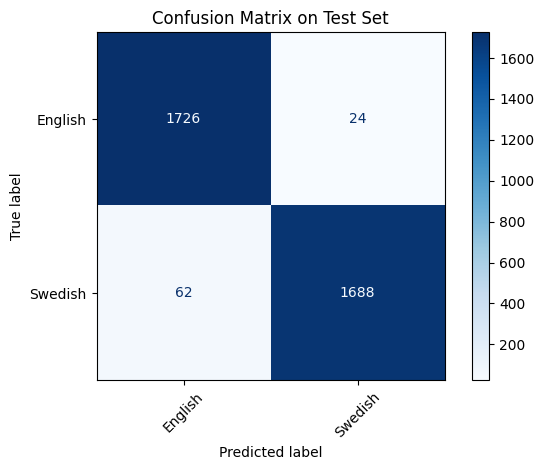

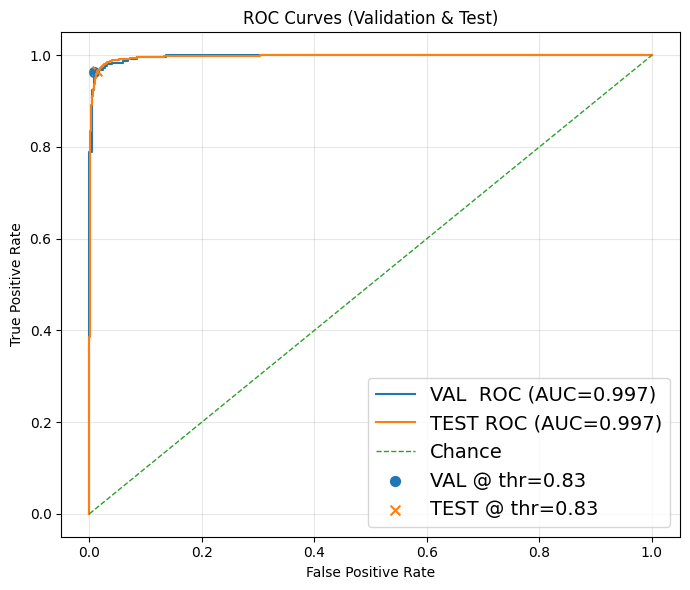

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_12_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])

#### 1s (k=25)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=25): train (976, 3200), val (476, 3200), test (3476, 3200)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [9.64254083e-04 1.71898573e-03 9.91675138e-01

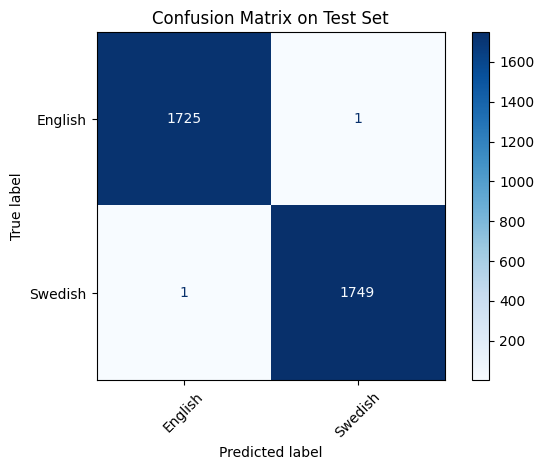

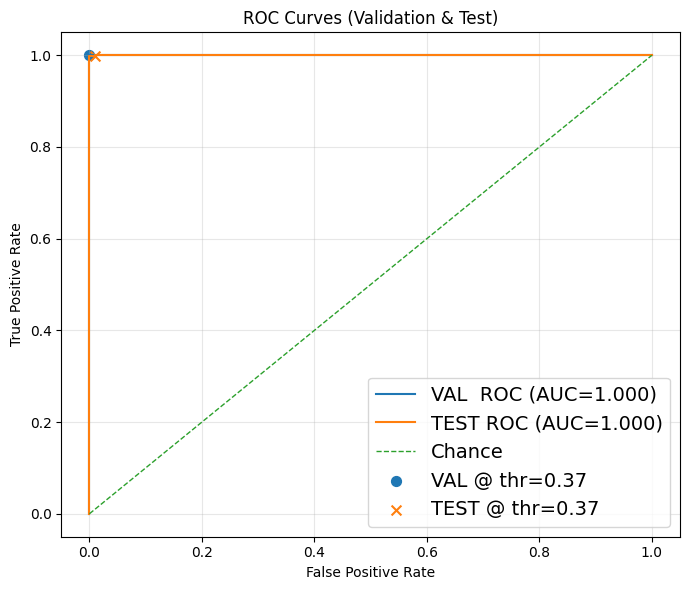

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_12_m_n_40ms, train_n=500, val_n=250, K = 25, class_names_list = ["English", "Swedish"])

#### 80 ms (k=2)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=2): train (999, 256), val (499, 256), test (3499, 256)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [1.50948064e-04 8.52824305e-04 8.40847790e-01 9.9

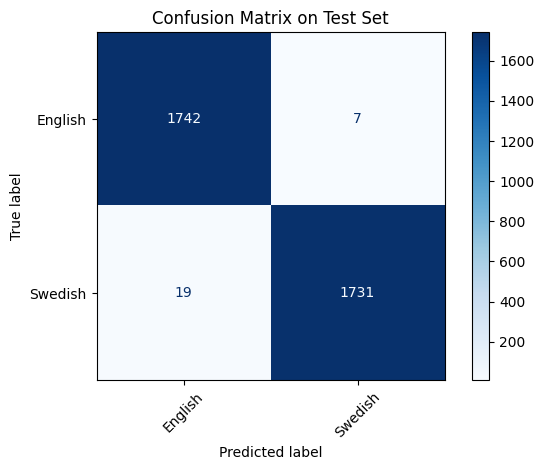

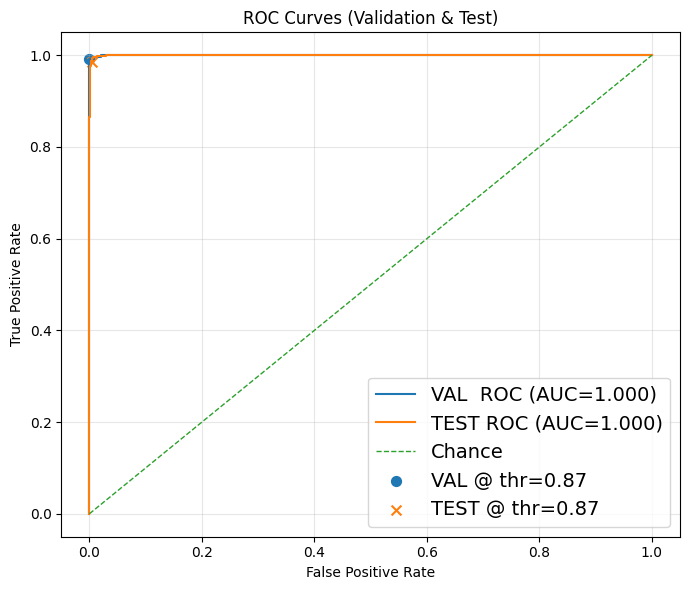

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_12_m_n_40ms, train_n=500, val_n=250, K = 2, class_names_list = ["English", "Swedish"])

#### 120 ms (k=3)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=3): train (998, 384), val (498, 384), test (3498, 384)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [5.49131830e-04 7.61593852e-04 6.25132412e-01 9.9

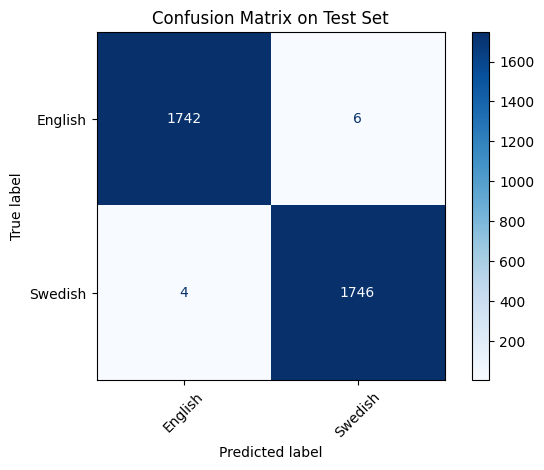

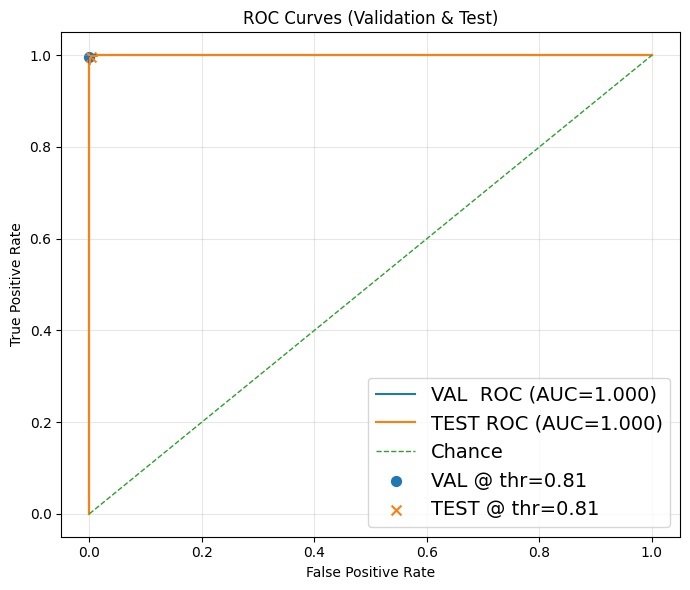

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_12_m_n_40ms, train_n=500, val_n=250, K = 3, class_names_list = ["English", "Swedish"])

#### 160 ms (k=4)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=4): train (997, 512), val (497, 512), test (3497, 512)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [6.70137175e-04 9.21585073e-04 6.89311981e-01 9.9

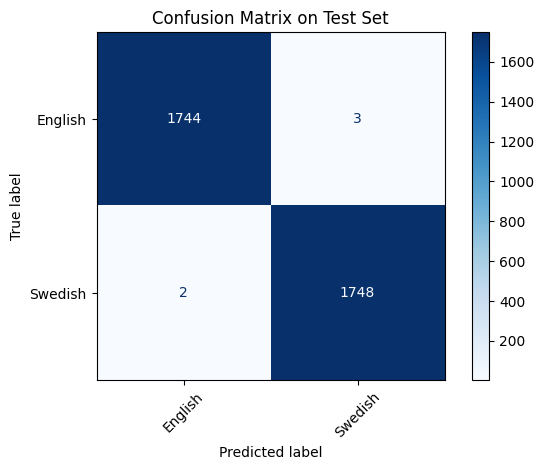

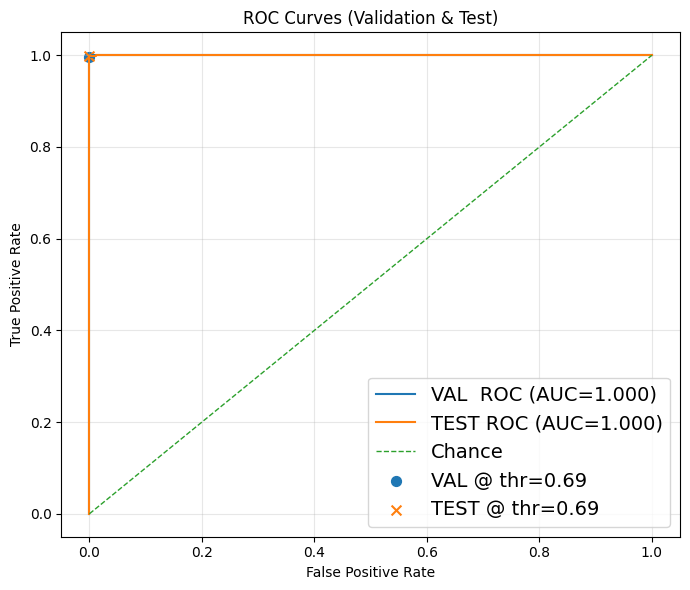

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_12_m_n_40ms, train_n=500, val_n=250, K = 4, class_names_list = ["English", "Swedish"])

#### 40ms (20 ms in calib 1-ms/10ms=train/val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

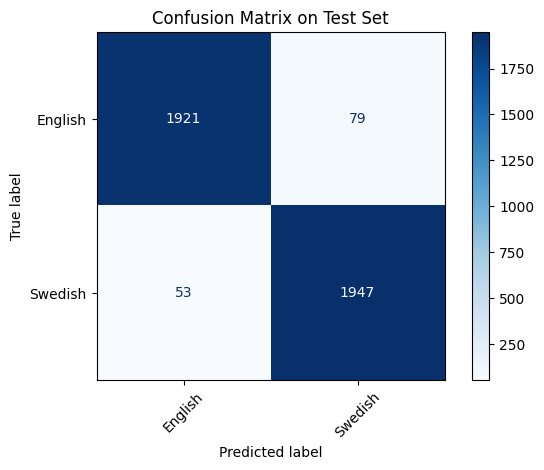

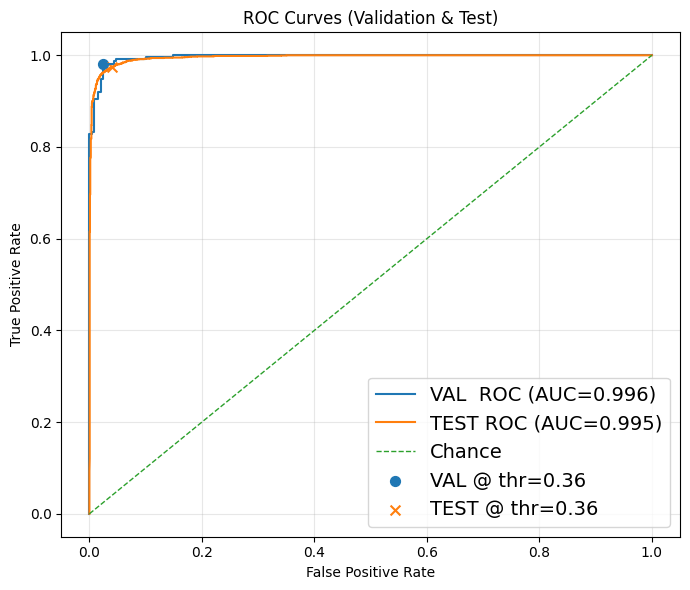

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_cc=train_and_eval_classifier_on_embeddings(
  test_12_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])

#### 40 ms 10ms in calib (150 chunks/100 chunks = train/val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

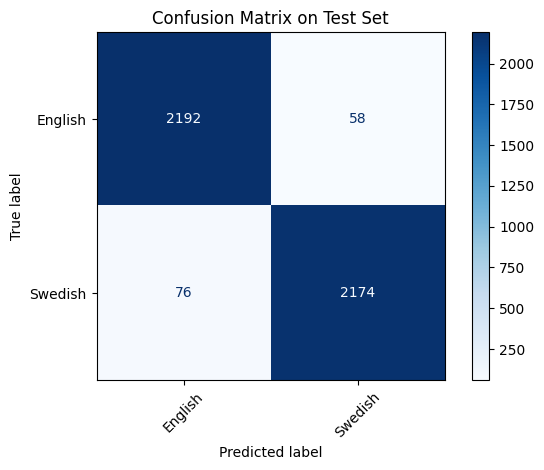

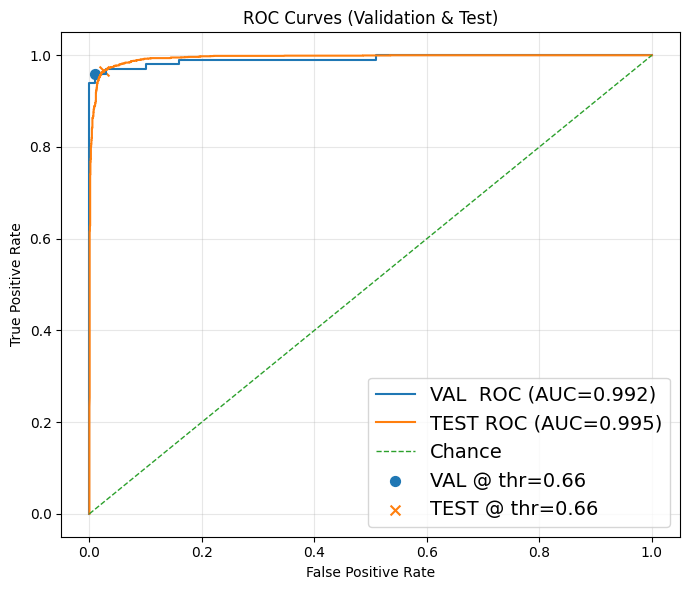

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_12_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])

## X13

#### 40 ms, k = 1, 30 ms calib (20 train, 10 val)

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (1000, 128), val (500, 128), test (3500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stoppi

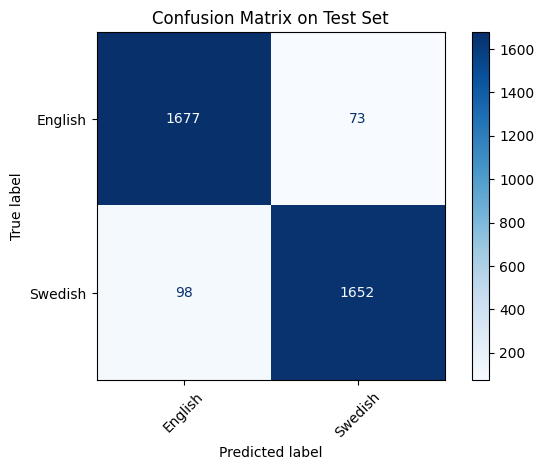

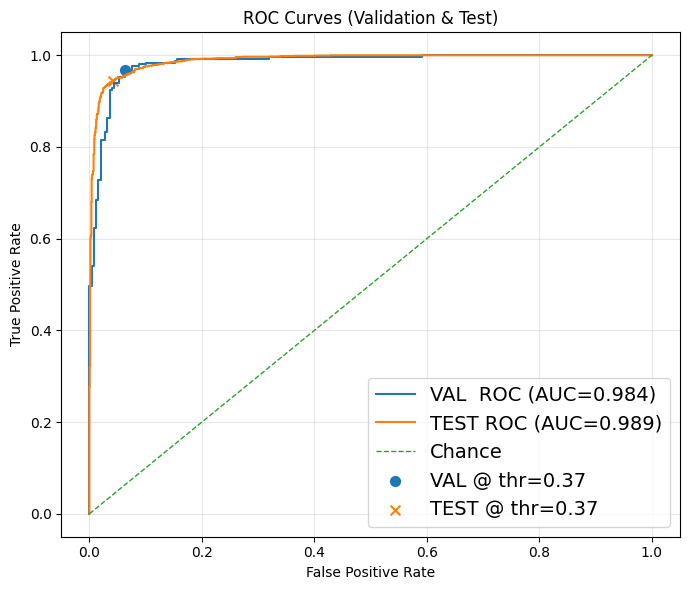

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_13_m_n_40ms, train_n=500, val_n=250, K = 1, class_names_list = ["English", "Swedish"])

#### 1s, k=25

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=25): train (976, 3200), val (476, 3200), test (3476, 3200)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [6.04711066e-04 2.13715684e-03 9.75489855e-01

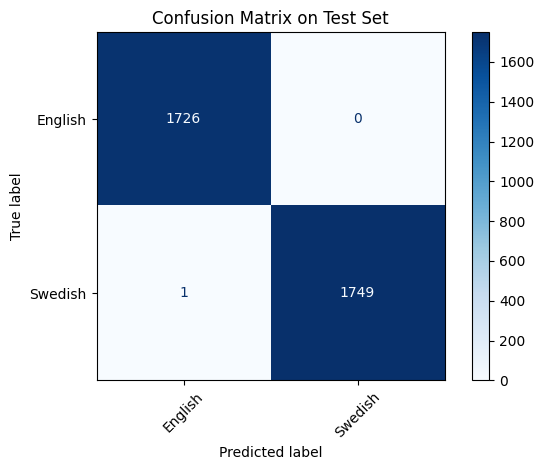

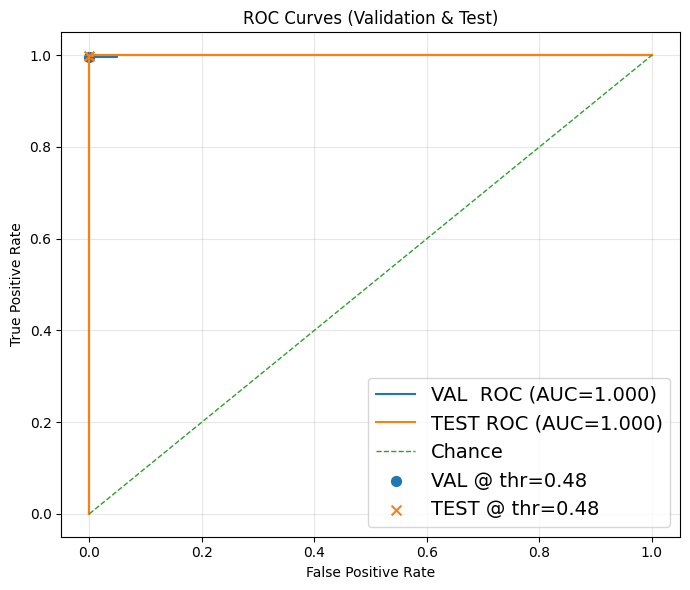

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_13_m_n_40ms, train_n=500, val_n=250, K = 25, class_names_list = ["English", "Swedish"])

#### 80ms, k=2

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=2): train (999, 256), val (499, 256), test (3499, 256)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [6.75858028e-05 3.70120644e-04 6.33920789e-01 9.9

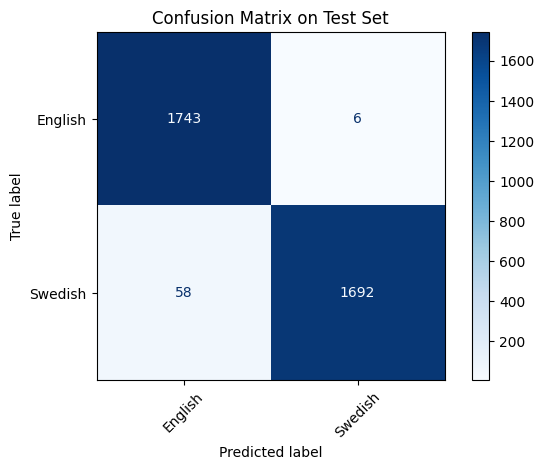

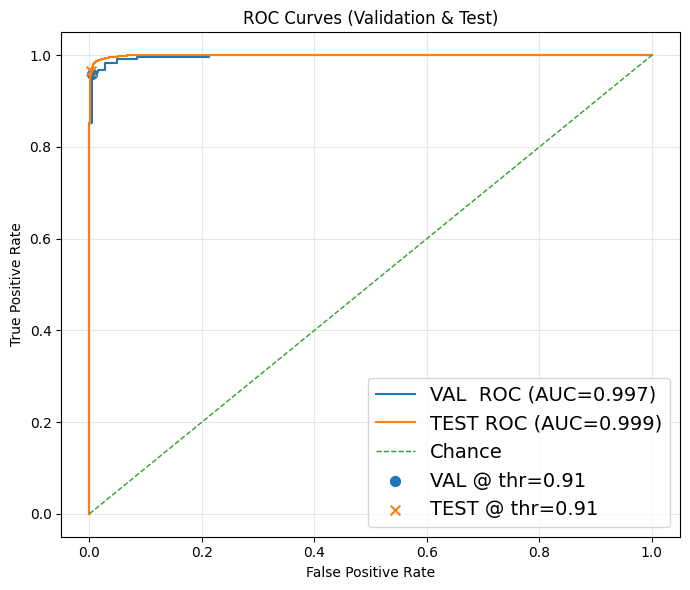

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_13_m_n_40ms, train_n=500, val_n=250, K = 2, class_names_list = ["English", "Swedish"])

#### 120ms, k=3

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=3): train (998, 384), val (498, 384), test (3498, 384)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [2.56761996e-04 8.61754423e-04 7.47177869e-01 9.9

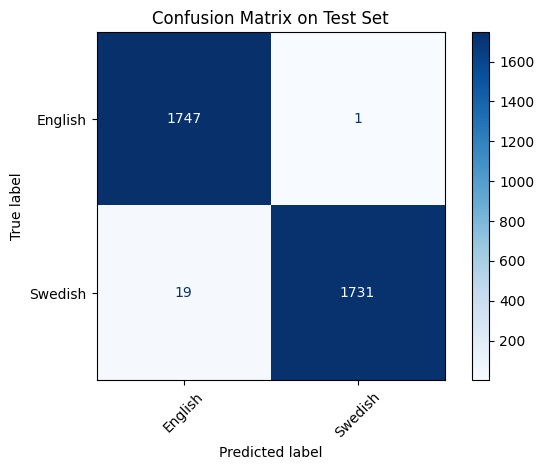

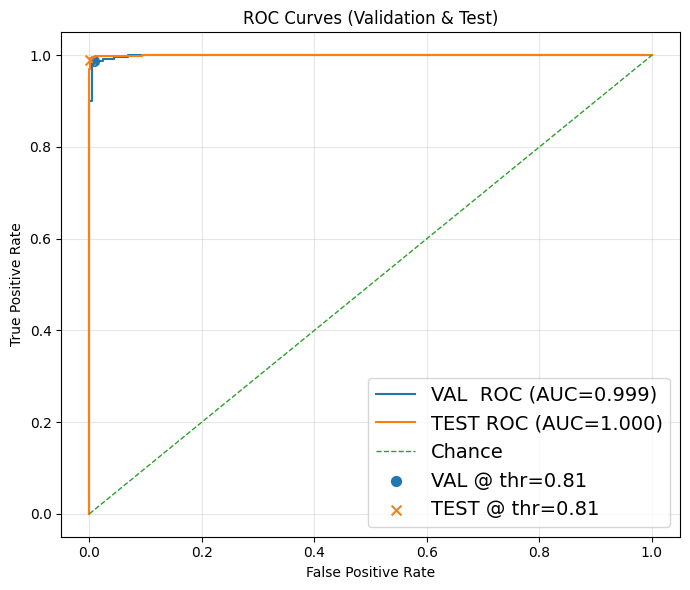

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_13_m_n_40ms, train_n=500, val_n=250, K = 3, class_names_list = ["English", "Swedish"])

#### 160ms, k=4

checkpoint.pt
max_chanks=500000
 x[0] shape is (500, 40, 32, 32, 1)
 x[1] shape is (500, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (1750, 40, 32, 32, 1)
 x[1] shape is (1750, 40, 32, 32, 1)
((2, 500, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 1750, 40, 32, 32, 1))
((1000, 40, 32, 32, 1), (500, 40, 32, 32, 1), (3500, 40, 32, 32, 1))
((1000, 1), (500, 1), (3500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (1000, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (3500, 128)
After temporal concat (K=4): train (997, 512), val (497, 512), test (3497, 512)
==> Training XGBoost on embeddings (no callbacks, no early stopping) ...
clf.classes_: [np.int64(0), np.int64(1)] | pos_col: 1
clf.classes_: [np.int64(0), np.int64(1)]
Chosen pos_col: 1
VAL prob quantiles: [4.14811482e-04 1.19836815e-03 8.51124227e-01 9.9

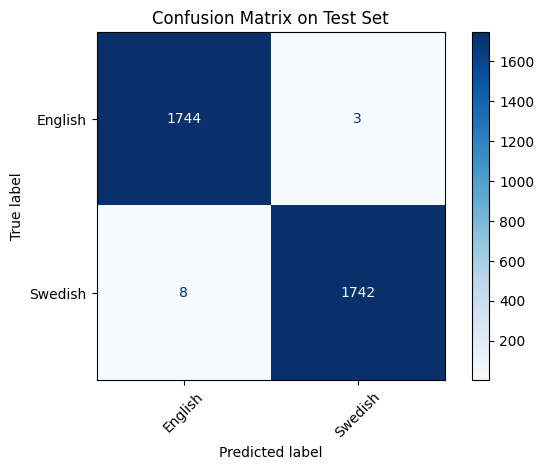

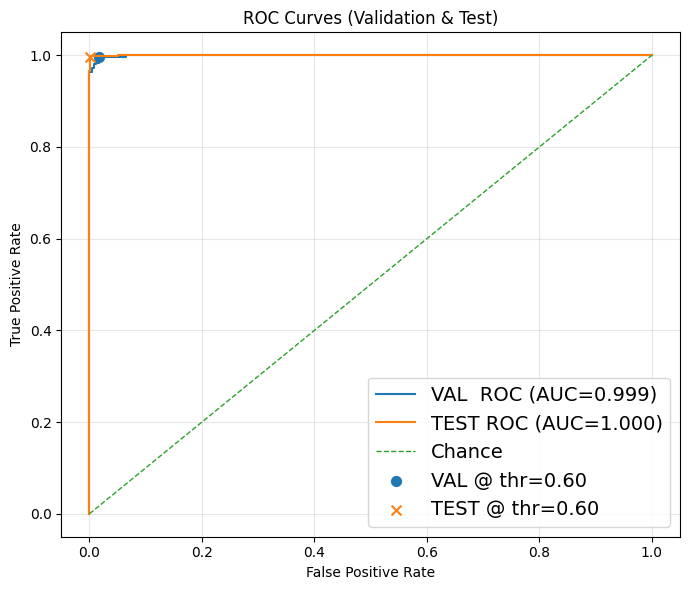

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_13_m_n_40ms, train_n=500, val_n=250, K = 4, class_names_list = ["English", "Swedish"])

#### 40 ms inputs, 20ms calib (10/10 ms=train/val of XGBoost)

checkpoint.pt
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (250, 40, 32, 32, 1)
 x[1] shape is (250, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2000, 40, 32, 32, 1)
 x[1] shape is (2000, 40, 32, 32, 1)
((2, 250, 40, 32, 32, 1), (2, 250, 40, 32, 32, 1), (2, 2000, 40, 32, 32, 1))
((500, 40, 32, 32, 1), (500, 40, 32, 32, 1), (4000, 40, 32, 32, 1))
((500, 1), (500, 1), (4000, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (500, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4000, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (500, 128), val (500, 128), test (4000, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

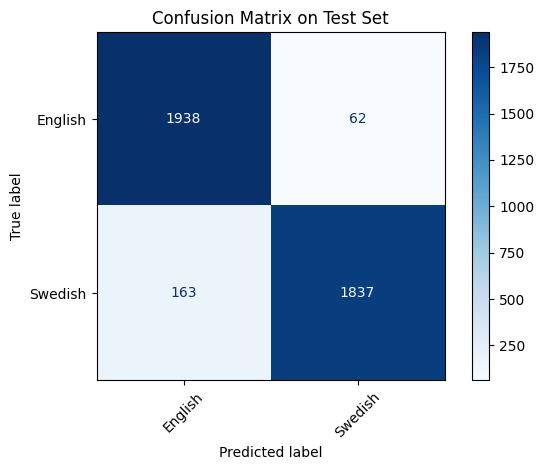

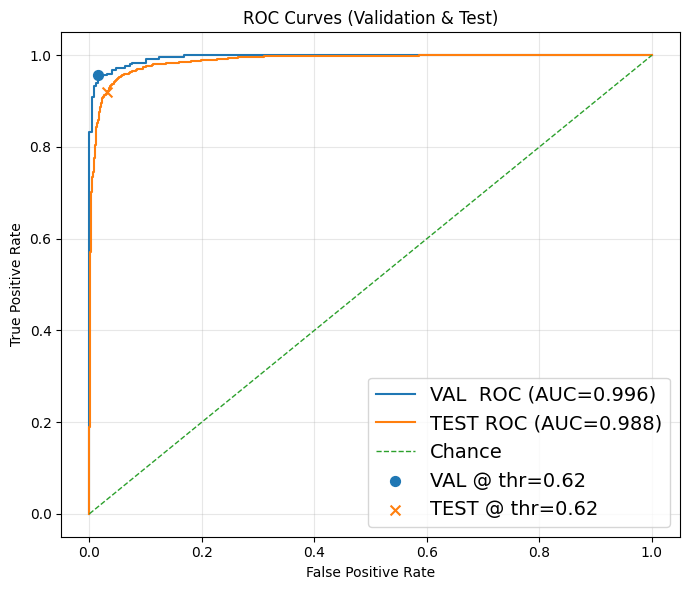

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_13_m_n_40ms, train_n=250, val_n=250, K = 1, class_names_list = ["English", "Swedish"])

#### 40 ms inputs, 10s calib (150/100 chunks of 40ms each=train/val of XGBoost)

checkpoint.pt
max_chanks=500000
 x[0] shape is (150, 40, 32, 32, 1)
 x[1] shape is (150, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (100, 40, 32, 32, 1)
 x[1] shape is (100, 40, 32, 32, 1)
max_chanks=500000
 x[0] shape is (2250, 40, 32, 32, 1)
 x[1] shape is (2250, 40, 32, 32, 1)
((2, 150, 40, 32, 32, 1), (2, 100, 40, 32, 32, 1), (2, 2250, 40, 32, 32, 1))
((300, 40, 32, 32, 1), (200, 40, 32, 32, 1), (4500, 40, 32, 32, 1))
((300, 1), (200, 1), (4500, 1))
==> Extracting embeddings (proj_dim) ...
Emb dims: set (300, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (200, 128)
==> Extracting embeddings (proj_dim) ...
Emb dims: set (4500, 128)
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
------------ cannot concatenate, returning a copy ------------
After temporal concat (K=1): train (300, 128), val (200, 128), test (4500, 128)
==> Training XGBoost on embeddings (no callbacks, no early stopping) 

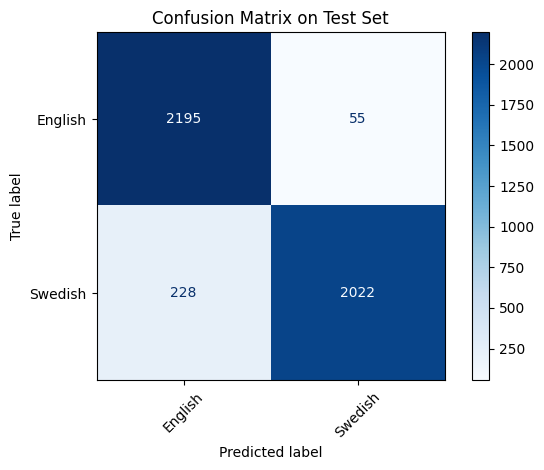

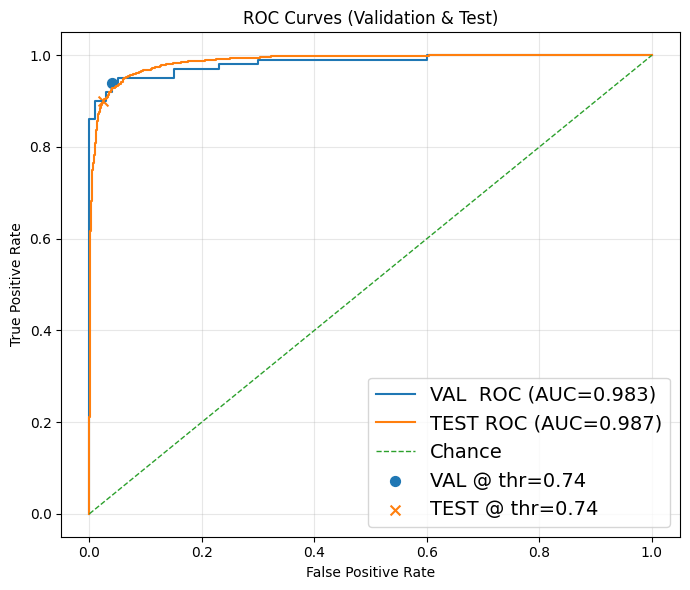

<Figure size 640x480 with 0 Axes>

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

clf,best_thr,val_auc,test_auc,prob_val,prob_test,y_c=train_and_eval_classifier_on_embeddings(
  test_13_m_n_40ms, train_n=150, val_n=100, K = 1, class_names_list = ["English", "Swedish"])

# Stats

## 20s calibraton

In [ ]:
import numpy as np
AUC_20 = np.array([
    1.000, 1.000, 0.999, 0.960, 0.997, 0.994, 0.873, 0.996, 0.996, 0.995, 0.978, 0.995, 0.988])
acc_20 = np.array([
    99.53, 99.40, 99.15, 89.10, 97.15, 99.42, 79.50, 99.55, 99.58, 99.52, 90.95, 96.70, 94.37])
F1_20 = np.array([1.00, 0.99, 0.99, 0.89, 0.97, 0.99, 0.80, 1.00, 1.00, 1.00, 0.91, 0.97, 0.95])
summarize(AUC_20, "AUC")
summarize(acc_20, "ACC")
summarize(F1_20, "F1")

AUC mean: 0.982385
AUC sample std: 0.034702
AUC 95% CI: [0.963520, 1.001249]

ACC mean: 95.686154
ACC sample std: 6.000004
ACC 95% CI: [92.424515, 98.947793]

F1 mean: 0.958462
F1 sample std: 0.059420
F1 95% CI: [0.926160, 0.990763]



## 10s calibration

In [ ]:
auc_10 = np.array([
    1.000, 1.000, 0.999, 0.954, 0.996, 0.993, 0.853, 0.996, 0.997, 0.994, 0.975, 0.995, 0.987])
acc_10 = np.array([
    99.53, 99.40, 99.15, 86.71, 95.40, 99.26, 76.80, 99.56, 99.67, 99.36, 91.44, 97.02, 94.71])
F1_10 = np.array([0.99, 0.99, 0.99, 0.87, 0.96, 0.99, 0.77, 1.00, 1.00, 0.99, 0.92, 0.97, 0.94])
summarize(auc_10, "AUC_10")
summarize(acc_10, "ACC_10")
summarize(F1_10, "F1_10")

AUC_10 mean: 0.979923
AUC_10 sample std: 0.040240
AUC_10 95% CI: [0.958048, 1.001798]

ACC_10 mean: 95.231538
ACC_10 sample std: 6.789258
ACC_10 95% CI: [91.540856, 98.922221]

F1_10 mean: 0.952308
F1_10 sample std: 0.066603
F1_10 95% CI: [0.916102, 0.988513]



## 30s calibration

In [ ]:
AUC_30 = np.array([
    1.000, 1.000, 1.000, 0.962, 0.998, 0.999, 0.901, 0.996, 0.998, 0.997, 0.984, 0.997, 0.989])
acc_30 = np.array([
    100.00, 99.51, 99.34, 90.06, 97.74, 99.92, 82.51, 99.56, 99.83, 99.69, 93.40, 97.54, 95.11])
F1_30 = np.array([1.00, 1.00, 0.99, 0.90, 0.98, 1.00, 0.83,1.00, 1.00, 1.00, 0.93, 0.98, 0.95])
summarize(AUC_30, "AUC_30")
summarize(acc_30, "ACC_30")
summarize(F1_30, "F1_30")

AUC_30 mean: 0.986231
AUC_30 sample std: 0.027689
AUC_30 95% CI: [0.971179, 1.001283]

ACC_30 mean: 96.477692
ACC_30 sample std: 5.188523
ACC_30 95% CI: [93.657179, 99.298205]

F1_30 mean: 0.966154
F1_30 sample std: 0.051887
F1_30 95% CI: [0.937948, 0.994360]



# Bar Graph

### run

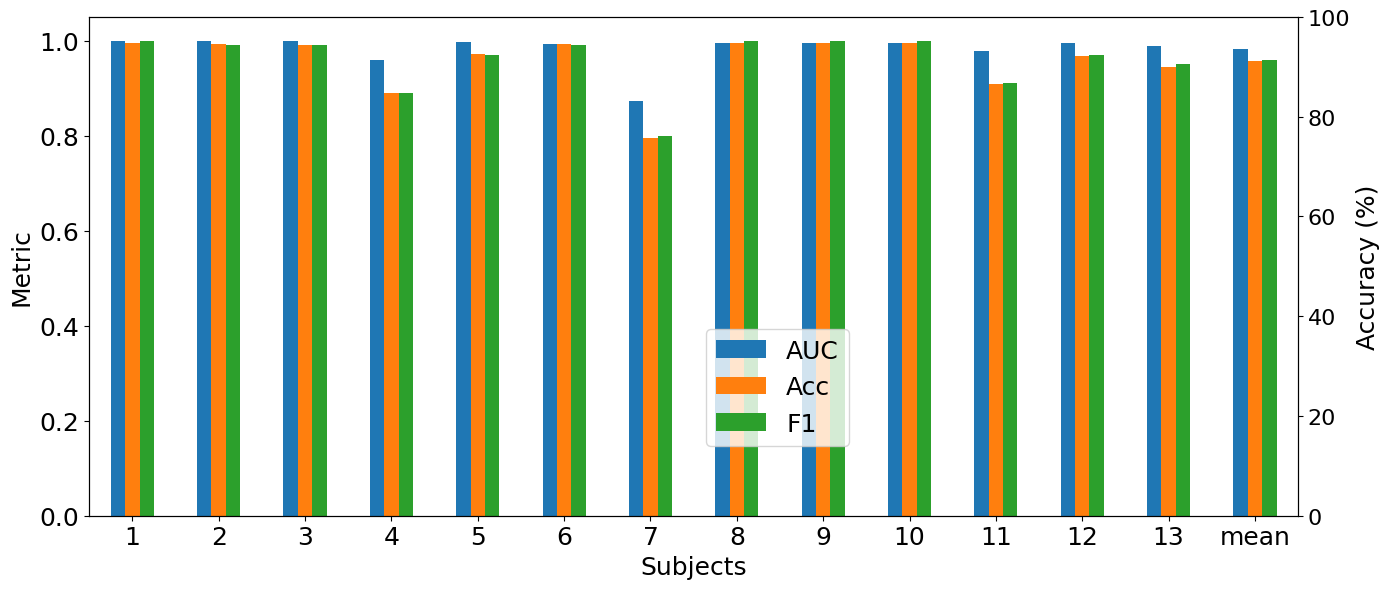

In [ ]:
metrics = {
    "AUC": AUC_20,
    "Acc": acc_20 / 100.0,   # scale to 0..1 for the left axis
    "F1": F1_20
}
df = plot_subject_metrics(metrics, color=["#1f77b4", "#ff7f0e", "#2ca02c"])

# Confusion Matrices

## multiple - 20s calibration

✅ All confusion matrices sum to 200% (row-normalized).


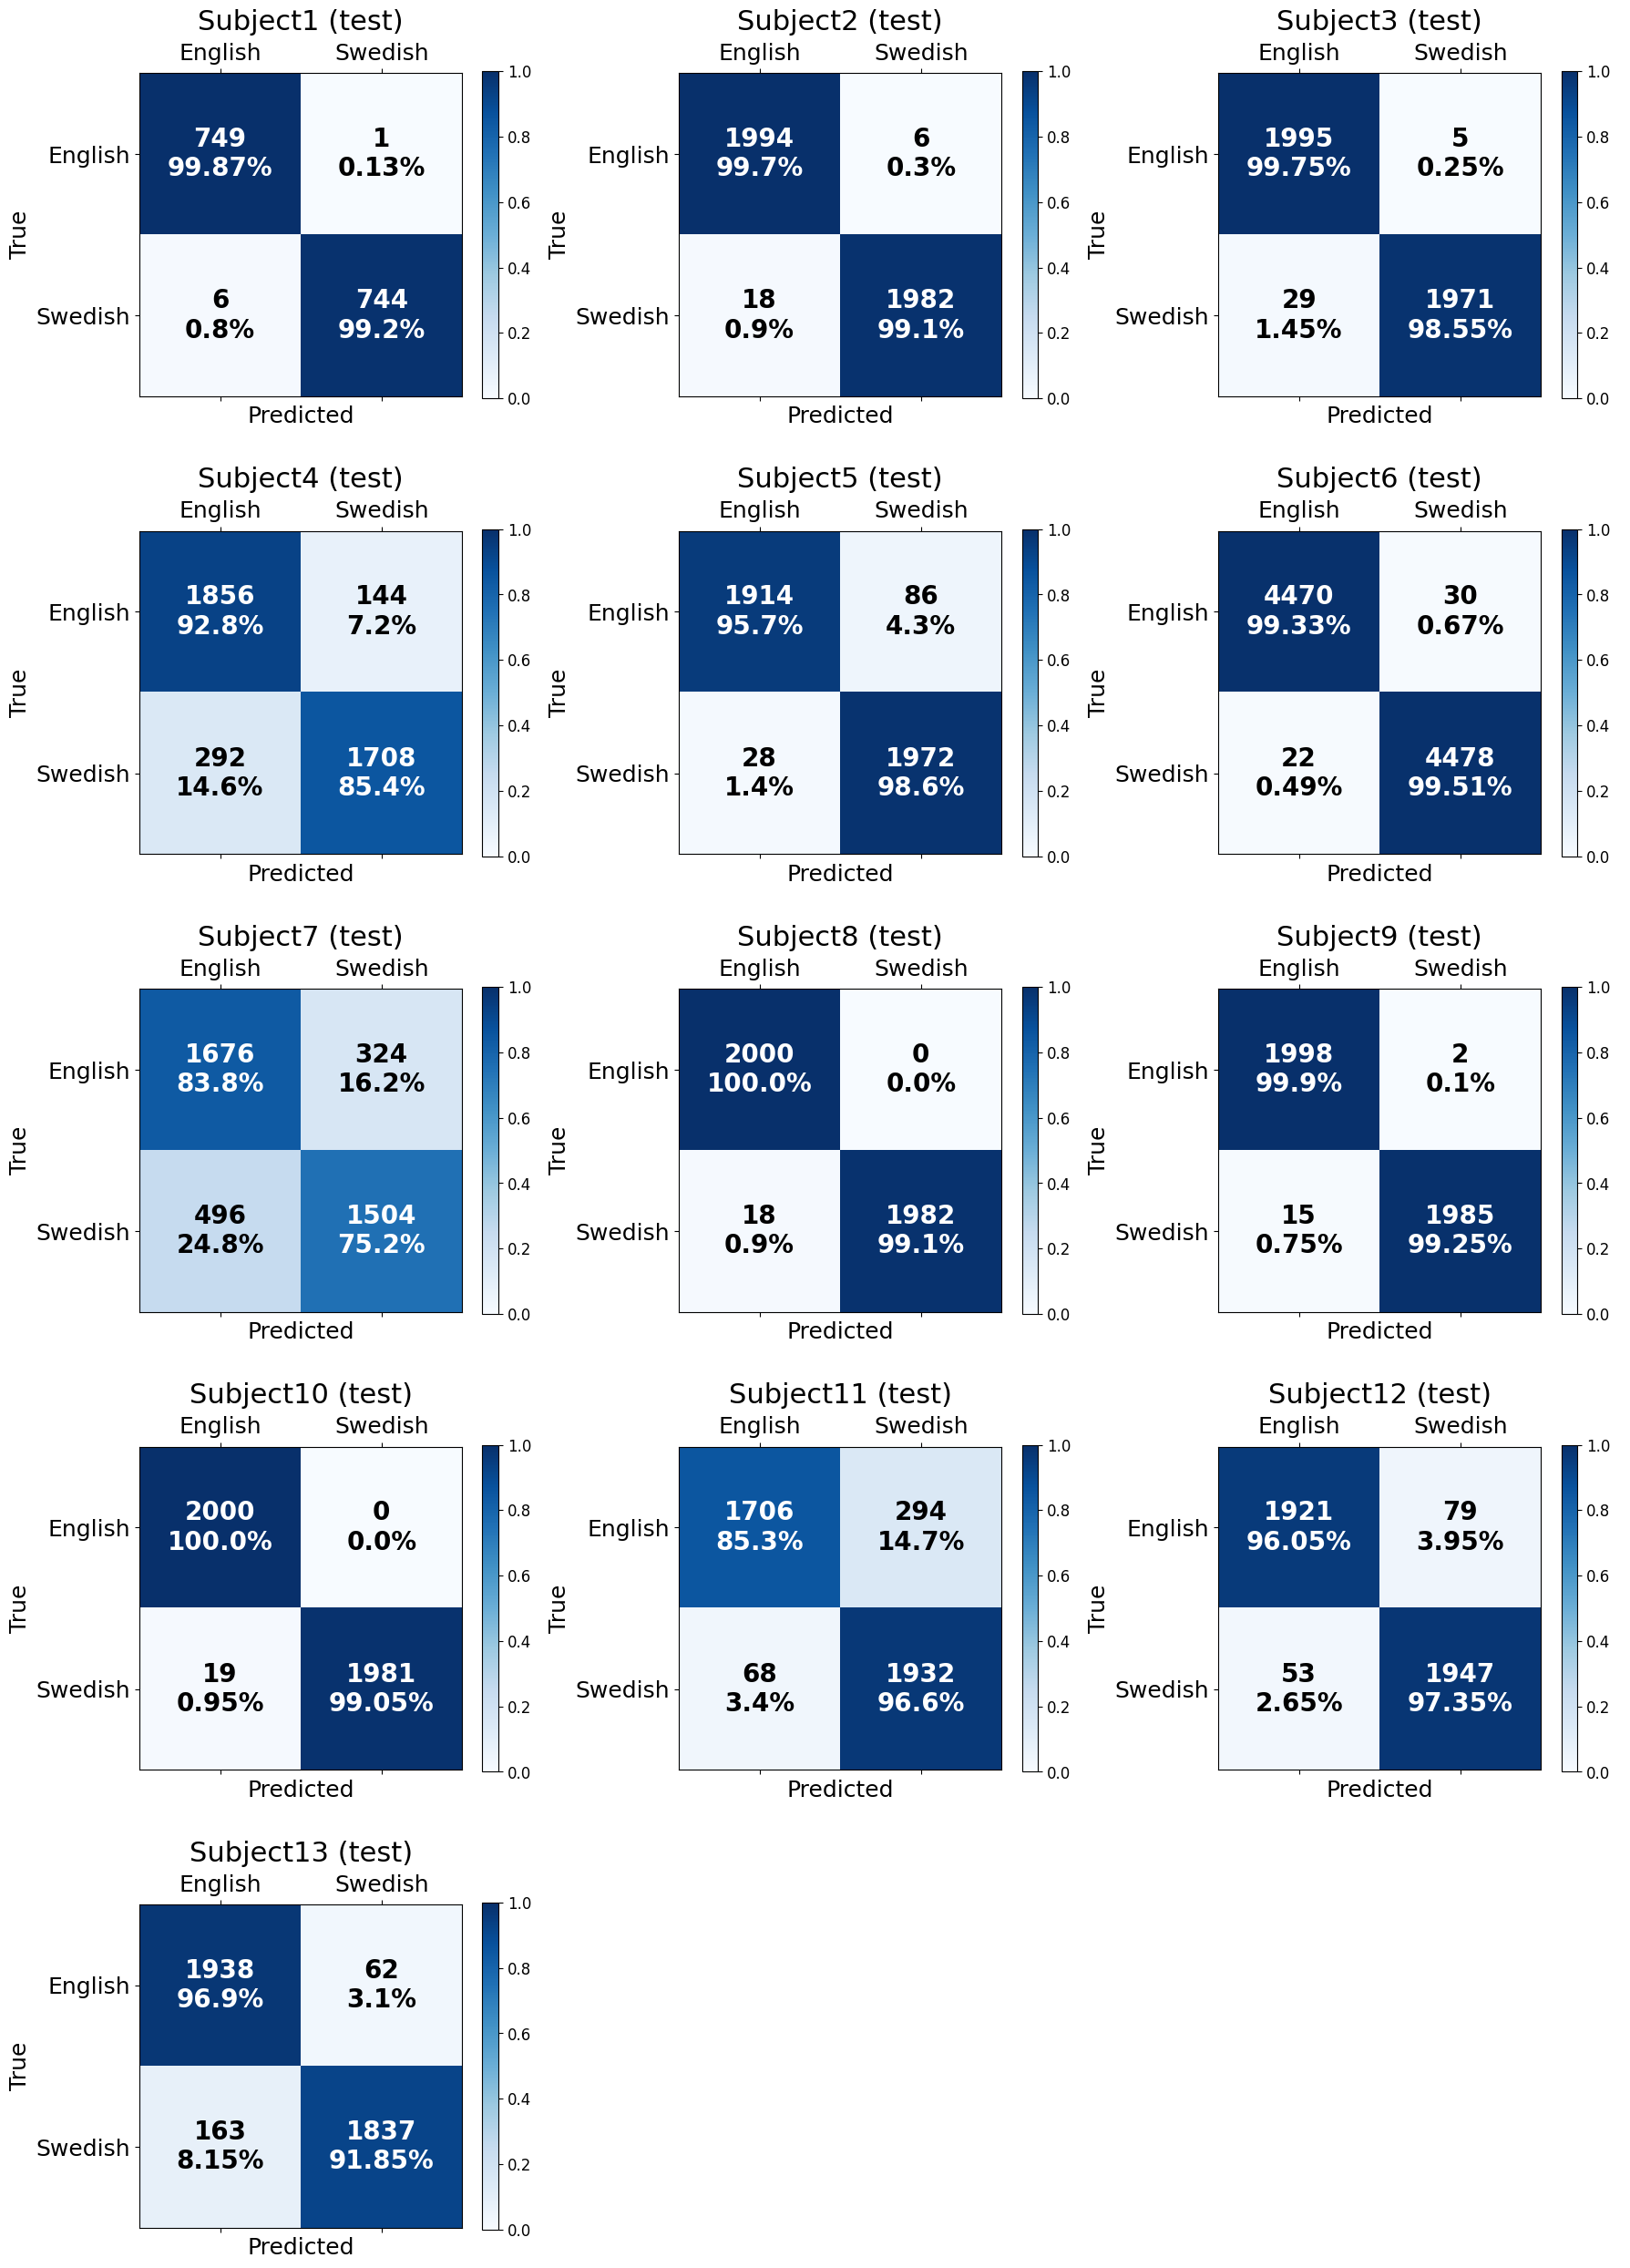

In [ ]:
import numpy as np
# 20 s in calibration (train/val=10s/10s)
cms = [
    np.array([[749,  1], #1
              [ 6, 744]]),
    np.array([[1994,  6], #2
              [ 18, 1982]]),
    np.array([[1995,  5], #3
              [ 29, 1971]]),
    np.array([[1856,  144],#4
              [ 292, 1708]]),
    np.array([[1914,  86], #5
              [ 28, 1972]]),
    np.array([[4470,  30], #6
              [ 22, 4478]]),
    np.array([[1676,  324], #7
              [ 496, 1504]]),
    np.array([[2000,  0], #8
              [ 18, 1982]]),
    np.array([[1998,  2], #9
              [ 15, 1985]]),
    np.array([[2000,  0], #10
              [ 19, 1981]]),
    np.array([[1706,  294], #11
              [ 68, 1932]]),
    np.array([[1921,  79], #12
              [ 53, 1947]]),
    np.array([[1938,  62], #13
              [ 163, 1837]]),
]

#[[TN, FP],
# [FN, TP]]

create_image_with_multiple_binary_confusion_matrices(cms=cms, captions=None,n_cols=3,
                    class_names=["English", "Swedish"], color_map='Blues')

## mean - 20s calibration

✅ All confusion matrices sum to 200% (row-normalized).


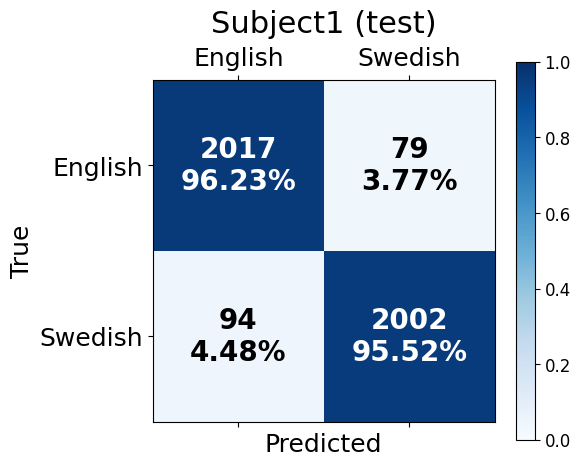

In [ ]:
create_image_with_mean_binary_confusion_matrix(cms=cms, captions=None,
                    class_names=["English", "Swedish"], color_map='Blues')

# PCA and Embeddings visualization

## 1

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (2500, 128)


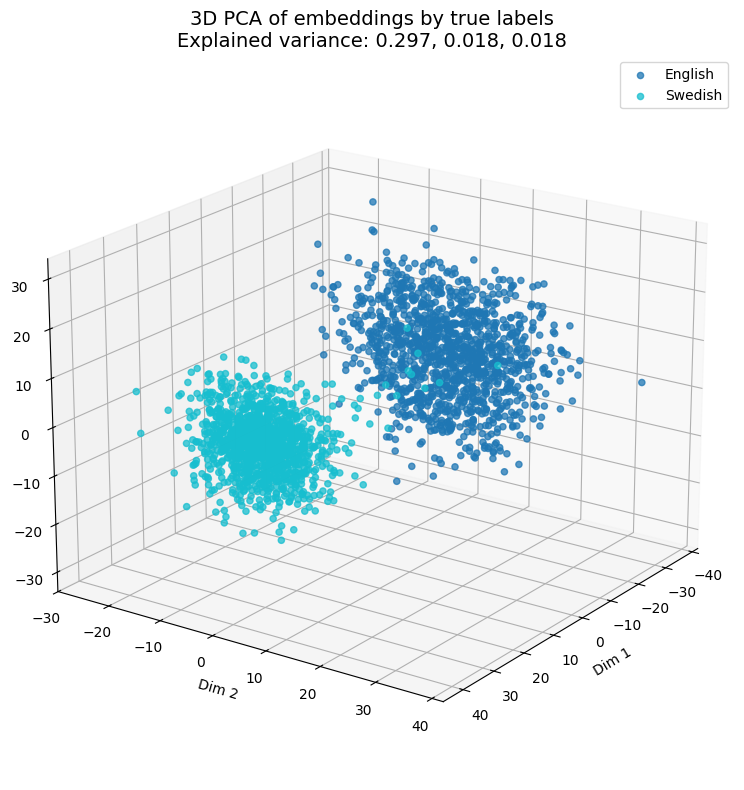

In [6]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model4_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x1_n_40ms, y1_n_40ms, class_names=["English", "Swedish"], K=25)

## 2

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


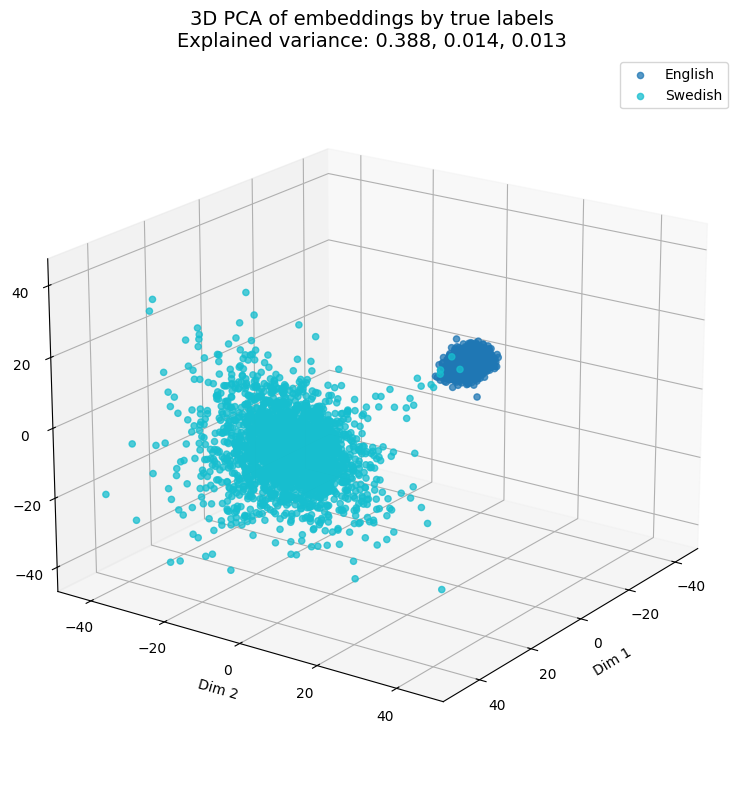

In [7]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model5_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x2_n_40ms, y2_n_40ms, class_names=["English", "Swedish"], K=25)

## 3

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


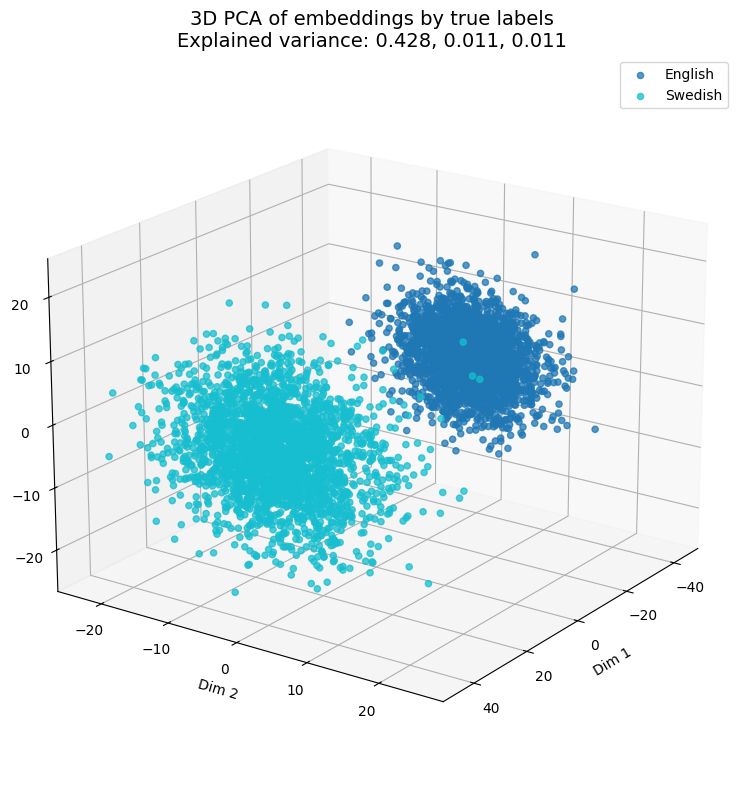

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x3_n_40ms, y3_n_40ms, class_names=["English", "Swedish"], K=25)

## 4

## 5

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


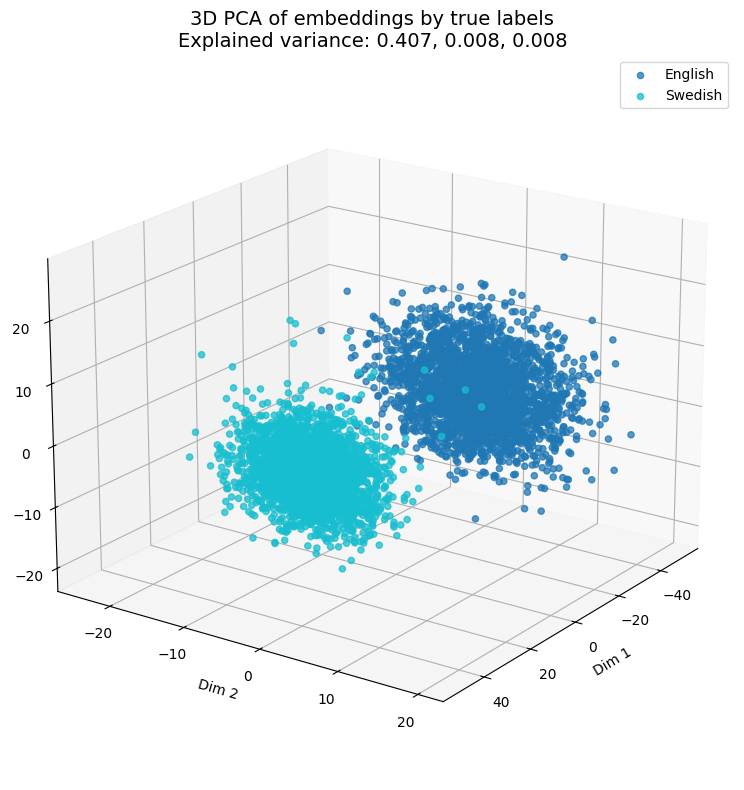

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model1_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x5_n_40ms, y5_n_40ms, class_names=["English", "Swedish"], K=25)

## 6

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (10000, 128)
------------ cannot concatenate, returning a copy ------------


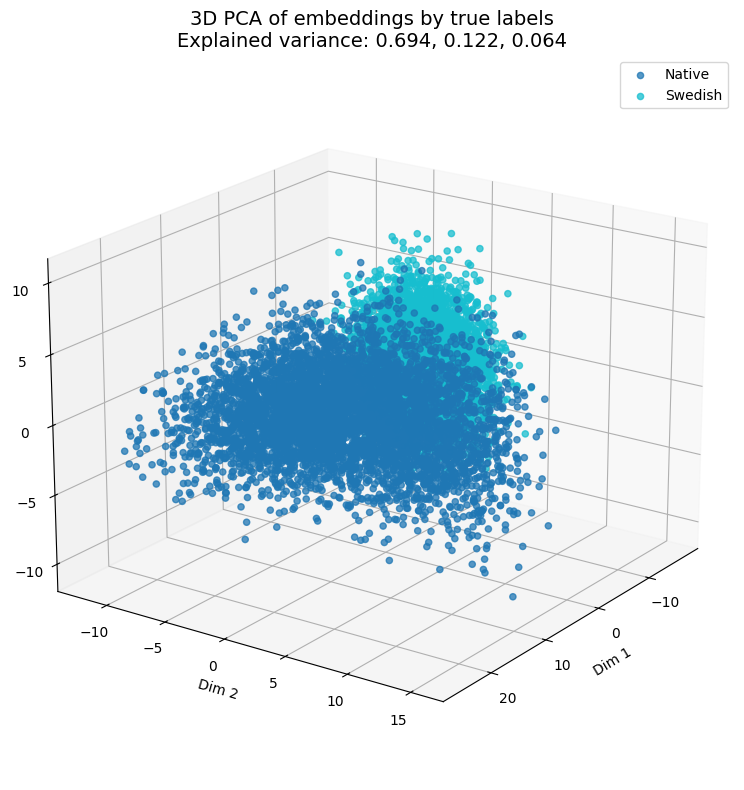

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model2_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x6_n_40ms, y6_n_40ms, class_names=["Native", "Swedish"])

## 7

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


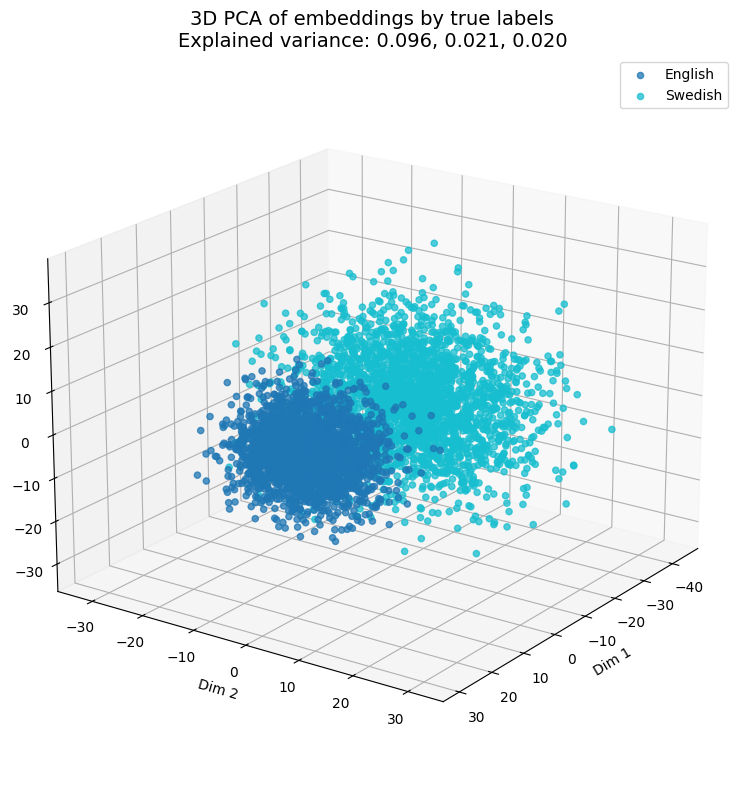

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model8_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x7_n_40ms, y7_n_40ms, class_names=["English", "Swedish"], K=25)

## 8

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


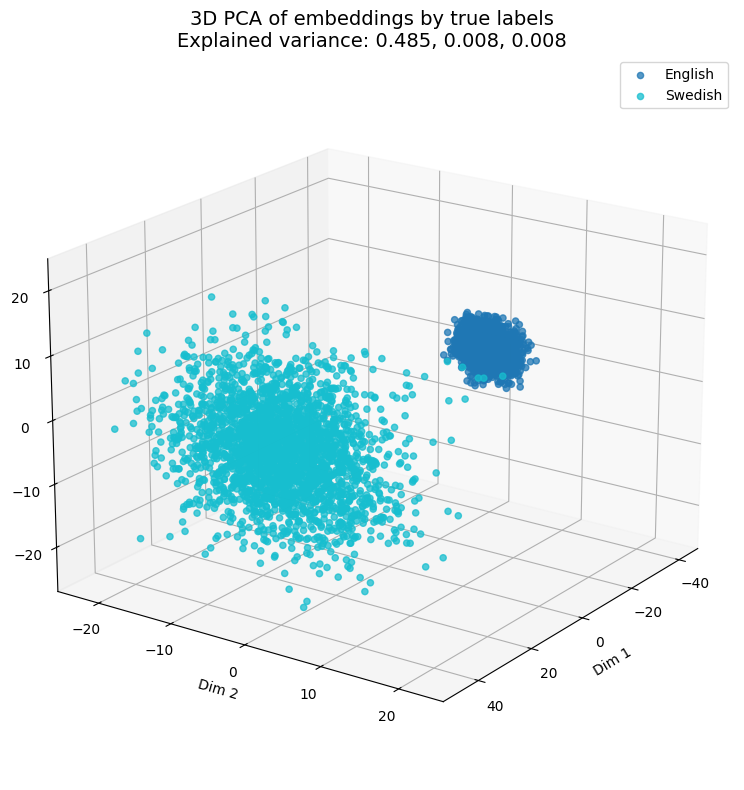

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model9_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x8_n_40ms, y8_n_40ms, class_names=["English", "Swedish"], K=25)

## 9

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


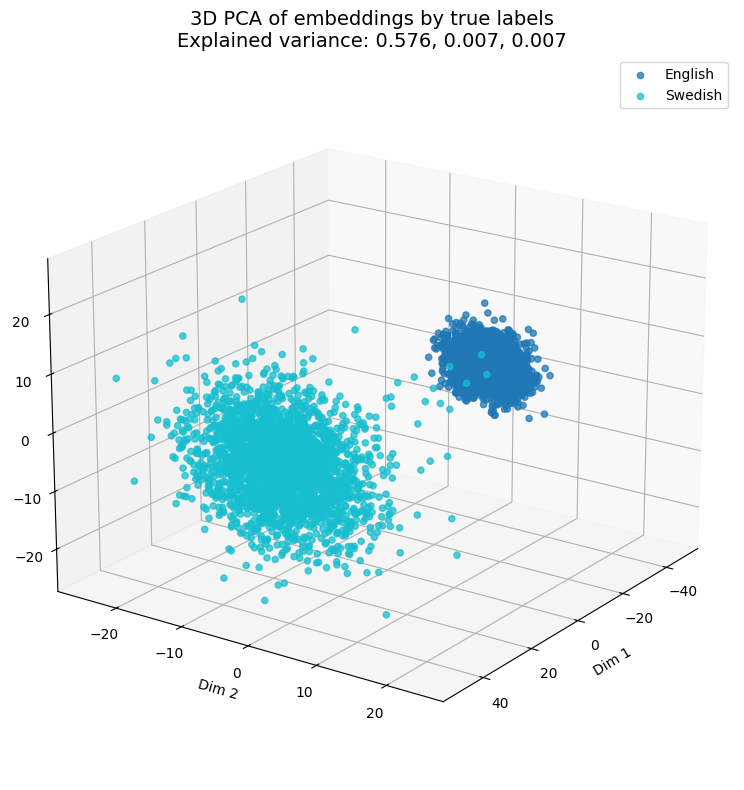

In [10]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x9_n_40ms, y9_n_40ms, class_names=["English", "Swedish"], K=25)

## 10

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


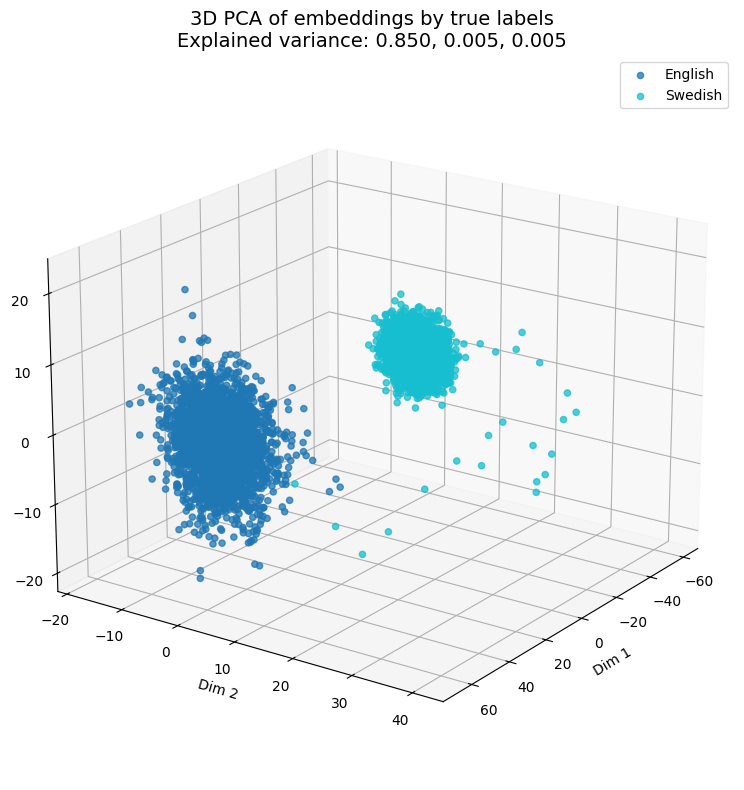

In [9]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model10_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x10_n_40ms, y10_n_40ms, class_names=["English", "Swedish"], K=25)

## 11

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


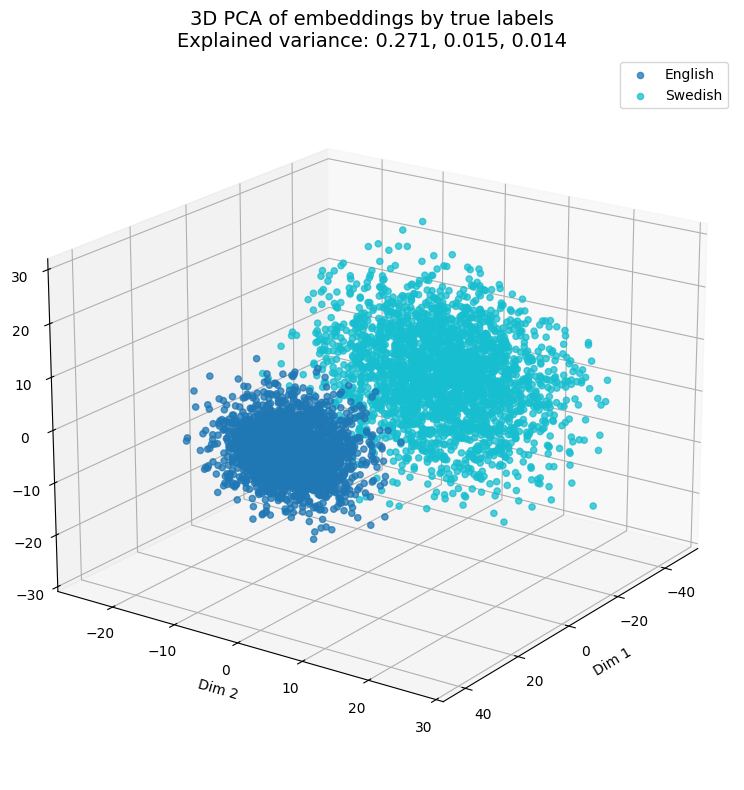

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model3_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x11_n_40ms, y11_n_40ms, class_names=["English", "Swedish"], K=25)

## 12

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


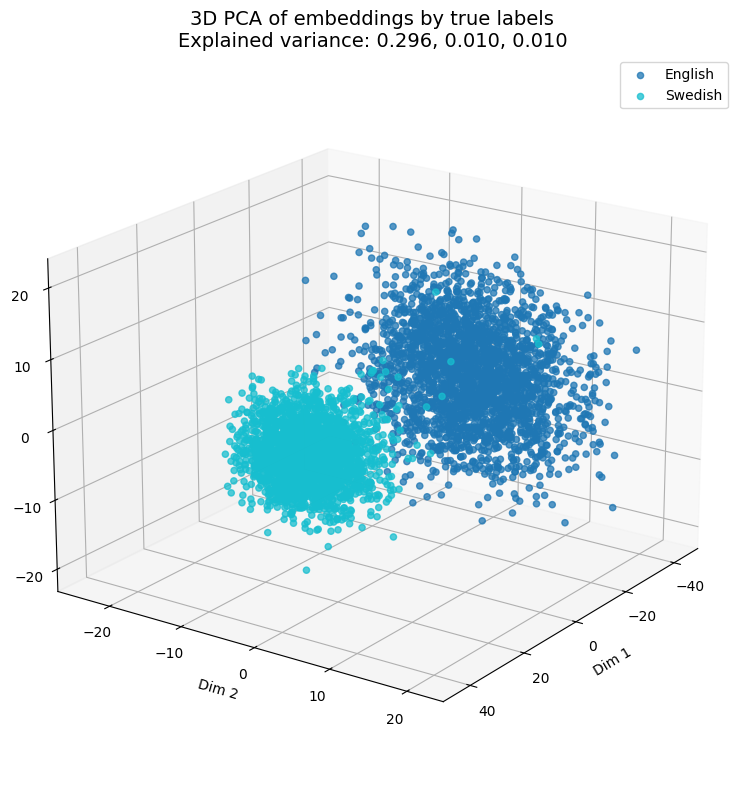

In [ ]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model6_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x12_n_40ms, y12_n_40ms, class_names=["English", "Swedish"], K=25)

## 13

checkpoint.pt
==> Extracting embeddings (proj_dim) ...
Emb dims: set (5000, 128)


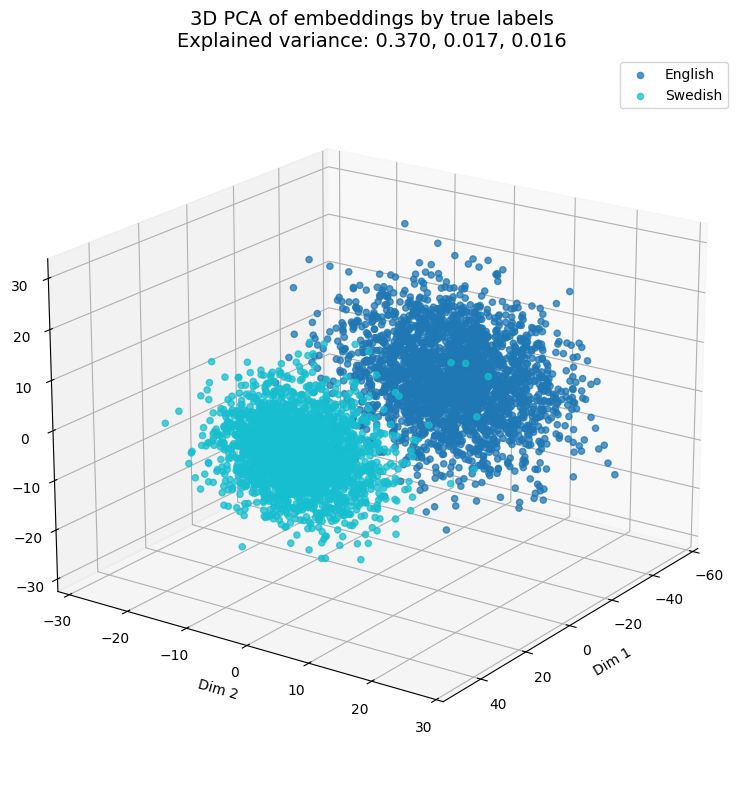

In [8]:
!cp -r gdrive/MyDrive/__PHd_2025/code_and_data/code/BCI_LvMAE_models_9_1/model7_30epochs/artifacts_lvmae_1 .
!ls artifacts_lvmae_1

X_pca_3d, pca = create_and_visualize_embeddings_3d(x13_n_40ms, y13_n_40ms, class_names=["English", "Swedish"], K=25)